
# miRNA qPCR Reanalysis Notebook

## Opening overview

**Purpose.** Reanalyze salivary miRNA qPCR data across periodontal groups with transparent, notebook-native computations.

**Governing inputs.**
1. `miRNA-qPCR-reanalysis.md` (workflow specification)
2. `miRNA-qPCR-analysis-results.csv` (primary data)

**Fixed group definitions.**
- `S` = Healthy
- `G` = Gingivitis
- `P` = Periodontitis

**Fixed tasks.**
- Task 1: `S` vs `G`
- Task 2: `G` vs `P`
- Task 3: `S` vs `P`

**Analytical scope.** Data validation, transformations, descriptive and inferential analyses, leakage-safe modeling, robustness checks, and final synthesis.

**Reproducibility promise.** All observable computations occur inside notebook cells, and the notebook is designed to run top-to-bottom from a fresh kernel.


In [31]:
# Section 1-2: environment and setup
import importlib
import os
import subprocess
import sys
from pathlib import Path
from urllib.request import urlopen

REQUIRED_FILENAMES = ['miRNA-qPCR-reanalysis.md', 'miRNA-qPCR-analysis-results.csv']
RAW_BASE_URL = 'https://raw.githubusercontent.com/Centaurioun/miRNA-analysis/main'

def has_required_files(root: Path, required_filenames):
    return all((root / f).exists() for f in required_filenames)

def try_download_required_files(target_root: Path, required_filenames):
    target_root.mkdir(parents=True, exist_ok=True)
    downloaded = []
    for name in required_filenames:
        target = target_root / name
        if target.exists():
            continue
        url = f'{RAW_BASE_URL}/{name}'
        try:
            with urlopen(url) as r:
                content = r.read()
            target.write_bytes(content)
            downloaded.append(name)
        except Exception as e:
            print(f'Warning: could not download {name} from {url}: {e}')
    return downloaded

def find_project_root(required_filenames):
    cwd = Path.cwd().resolve()
    search_roots = [cwd] + list(cwd.parents)
    for root in search_roots:
        if has_required_files(root, required_filenames):
            return root

    env_root = os.getenv('MIRNA_PROJECT_ROOT')
    if env_root:
        env_path = Path(env_root).expanduser().resolve()
        if has_required_files(env_path, required_filenames):
            return env_path

    fallback_candidates = [
        Path('/Users/centaurioun/Repos/miRNA-analysis'),
        Path.home() / 'Repos' / 'miRNA-analysis',
    ]
    for root in fallback_candidates:
        if has_required_files(root, required_filenames):
            return root

    # If workspace files are not mounted in this runtime, fetch repo files to cwd
    downloaded = try_download_required_files(cwd, required_filenames)
    if downloaded:
        print('Downloaded missing required files into runtime:', downloaded)
    if has_required_files(cwd, required_filenames):
        return cwd

    raise FileNotFoundError(
        f'Could not locate or fetch required files: {required_filenames}. CWD={cwd}'
    )

ROOT_DIR = find_project_root(REQUIRED_FILENAMES)
print('Resolved ROOT_DIR:', ROOT_DIR)

required_packages = [
    'numpy', 'pandas', 'scipy', 'matplotlib', 'seaborn', 'sklearn', 'statsmodels', 'tabulate'
 ]
missing = []
for pkg in required_packages:
    try:
        importlib.import_module(pkg)
    except ImportError:
        missing.append(pkg)

if missing:
    print('Installing missing packages:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
else:
    print('All required packages already available.')

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    precision_score, recall_score
 )
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import multipletests

np.random.seed(42)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

OUTPUT_DIR = ROOT_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

import sklearn, statsmodels, matplotlib
print('Python:', sys.version.split()[0])
print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('scipy:', scipy.__version__)
print('sklearn:', sklearn.__version__)
print('statsmodels:', statsmodels.__version__)
print('matplotlib:', matplotlib.__version__)


Resolved ROOT_DIR: /Users/centaurioun/Repos/miRNA-analysis
All required packages already available.
Python: 3.13.11
pandas: 3.0.1
numpy: 2.4.3
scipy: 1.17.1
sklearn: 1.8.0
statsmodels: 0.14.6
matplotlib: 3.10.8


In [32]:
# Section 3-4: file checks and specification ingestion
spec_path = ROOT_DIR / 'miRNA-qPCR-reanalysis.md'
data_path = ROOT_DIR / 'miRNA-qPCR-analysis-results.csv'

if not spec_path.exists() or not data_path.exists():
    missing_files = [str(p) for p in [spec_path, data_path] if not p.exists()]
    raise FileNotFoundError(f'Missing required files: {missing_files}')

spec_text = spec_path.read_text(encoding='utf-8')
print('Specification file loaded. Characters:', len(spec_text))

# Lightweight directive map derived from headings
lines = [ln.strip() for ln in spec_text.splitlines() if ln.strip().startswith('#')]
directive_map = pd.DataFrame({'Heading': lines})
directive_map.head(20)


Specification file loaded. Characters: 20820


,Heading
0,# IPynb Prompt and Workflow v2
1,# PART I — MASTER PROMPT FOR THE NOTEBOOK-BUIL...
2,## Task
3,## Primary deliverable
4,## Core execution doctrine
5,### 1) The notebook is the visible source of t...
6,"### 2) The notebook must be auditable, not mer..."
7,### 3) Use the active notebook runtime
8,### 4) Clean rerun from a fresh kernel is mand...
9,### 5) Raw-data-first discipline


## Section 5 — Input registry and assumption ledger

In [33]:

# Load raw data and create registry
raw_df = pd.read_csv(data_path)

expected_groups = {'S','G','P'}
expected_global_cols = ['global_mean_ct_all7', 'global_mean_ct_miRNA_only']

input_registry = pd.DataFrame([
    {'Item':'Specification file', 'Available': spec_path.exists(), 'Details': str(spec_path)},
    {'Item':'Primary CSV', 'Available': data_path.exists(), 'Details': str(data_path)},
    {'Item':'Rows in CSV', 'Available': True, 'Details': raw_df.shape[0]},
    {'Item':'Columns in CSV', 'Available': True, 'Details': raw_df.shape[1]},
    {'Item':'Expected groups present exactly', 'Available': set(raw_df['GROUP'].unique())==expected_groups, 'Details': sorted(raw_df['GROUP'].unique().tolist())},
])

assumptions = [
    ['A1','Ct columns are numeric and lower Ct implies higher abundance.','Needed for transformation directionality.','qPCR Ct convention + column names `mean_*`.','If reversed, biological interpretation flips.','Transformations, interpretation'],
    ['A2','`mean_GAPDH` is reference Ct usable for ΔCt.','Needed for normalization strategy.','Column present in CSV.','Normalization may be unstable if reference unsuitable.','Transformation, sensitivity analyses'],
    ['A3','`global_mean_ct_all7` and `global_mean_ct_miRNA_only` are not present; proxy summaries are computed and labeled.','Specification asks explicit broader/global checks.','Columns absent in CSV.','Proxy may not fully match intended variables.','Broader/global structure section'],
    ['A4','Binary modeling uses logistic regression with nested CV and default 0.5 threshold for primary estimates.','Needed for leakage-safe consistent discrimination checks.','Transparent implementation in notebook cells.','Threshold-dependent metrics could differ under clinical calibration.','Modeling and performance interpretation'],
]

assumption_ledger = pd.DataFrame(assumptions, columns=['Assumption_ID','Assumption','Why needed','Evidence','Risk if wrong','Affected sections'])

input_registry


,Item,Available,Details
0,Specification file,True,/Users/centaurioun/Repos/miRNA-analysis/miRNA-...
1,Primary CSV,True,/Users/centaurioun/Repos/miRNA-analysis/miRNA-...
2,Rows in CSV,True,108
3,Columns in CSV,True,15
4,Expected groups present exactly,True,"[G, P, S]"


In [34]:
assumption_ledger


,Assumption_ID,Assumption,Why needed,Evidence,Risk if wrong,Affected sections
0,A1,Ct columns are numeric and lower Ct implies hi...,Needed for transformation directionality.,qPCR Ct convention + column names `mean_*`.,"If reversed, biological interpretation flips.","Transformations, interpretation"
1,A2,`mean_GAPDH` is reference Ct usable for ΔCt.,Needed for normalization strategy.,Column present in CSV.,Normalization may be unstable if reference uns...,"Transformation, sensitivity analyses"
2,A3,`global_mean_ct_all7` and `global_mean_ct_miRN...,Specification asks explicit broader/global che...,Columns absent in CSV.,Proxy may not fully match intended variables.,Broader/global structure section
3,A4,Binary modeling uses logistic regression with ...,Needed for leakage-safe consistent discriminat...,Transparent implementation in notebook cells.,Threshold-dependent metrics could differ under...,Modeling and performance interpretation



### Checkpoint — What was found and what happens next
1. **What was analyzed:** File presence, specification ingestion, and assumptions required for workflow completion.
2. **Main findings:** Required files are available; some specification-requested global variables are absent in CSV and need explicit proxy handling.
3. **What appears robust:** Group labels and primary qPCR variables are present.
4. **What appears fragile/incomplete:** Global summary variables requested by name are unavailable.
5. **Alternative explanations:** Source dataset may be a reduced export lacking precomputed global Ct fields.
6. **Next step:** Perform full schema validation, transformation logs, and audited preprocessing.


## Section 6-8 — Data loading, validation, discrepancy log, and transformations

In [35]:

df = raw_df.copy()

# Basic validation
validation_summary = {
    'shape': df.shape,
    'missing_per_column': df.isna().sum().to_dict(),
    'duplicate_rows': int(df.duplicated().sum()),
    'group_counts': df['GROUP'].value_counts().to_dict(),
    'sex_counts': df['SEX'].value_counts(dropna=False).to_dict(),
}
validation_summary


{'shape': (108, 15),
 'missing_per_column': {'GROUP': 0,
  'SEX': 0,
  'AGE': 0,
  'plaque_index': 0,
  'gingival_index': 0,
  'pocket_depth': 0,
  'bleeding_on_probing': 0,
  'number_of_missing_teeth': 0,
  'mean_mir146a': 0,
  'mean_mir146b': 0,
  'mean_mir155': 0,
  'mean_mir203': 0,
  'mean_mir223': 0,
  'mean_mir381p': 0,
  'mean_GAPDH': 0},
 'duplicate_rows': 0,
 'group_counts': {'S': 36, 'G': 36, 'P': 36},
 'sex_counts': {'F': 57, 'M': 51}}

In [36]:

# Variable typing and schema checks
miRNA_cols = [c for c in df.columns if c.startswith('mean_mir')]
clinical_cols = ['plaque_index','gingival_index','pocket_depth','bleeding_on_probing','number_of_missing_teeth']
demo_cols = ['AGE','SEX']
ref_col = 'mean_GAPDH'

for col in miRNA_cols + clinical_cols + ['AGE', ref_col]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['GROUP'] = df['GROUP'].astype('category')
df['SEX'] = df['SEX'].astype('category')

# Discrepancy log
expected_elements = {
    'global_mean_ct_all7': 'not found' if 'global_mean_ct_all7' not in df.columns else 'found',
    'global_mean_ct_miRNA_only': 'not found' if 'global_mean_ct_miRNA_only' not in df.columns else 'found',
}

discrepancy_log = pd.DataFrame([
    {'Item':k, 'Status':v, 'Action':'Create proxy from available Ct columns and label clearly as proxy'}
    for k,v in expected_elements.items()
])

discrepancy_log


,Item,Status,Action
0,global_mean_ct_all7,not found,Create proxy from available Ct columns and lab...
1,global_mean_ct_miRNA_only,not found,Create proxy from available Ct columns and lab...


In [37]:

# Transformation log
transform_log = []

# 1) ΔCt = target - GAPDH
for c in miRNA_cols:
    new_col = c.replace('mean_', 'dct_')
    df[new_col] = df[c] - df[ref_col]
    transform_log.append((new_col, f'{c} - {ref_col}', 'Lower ΔCt indicates higher relative abundance'))

# 2) Abundance-oriented transform: -ΔCt
dct_cols = [c for c in df.columns if c.startswith('dct_mir')]
for c in dct_cols:
    new_col = c.replace('dct_', 'abd_')
    df[new_col] = -df[c]
    transform_log.append((new_col, f'-1 * {c}', 'Higher value indicates higher relative abundance proxy'))

# 3) Broader/global proxies if missing
if 'global_mean_ct_all7' not in df.columns:
    df['global_mean_ct_all7_proxy'] = df[miRNA_cols + [ref_col]].mean(axis=1)
    transform_log.append(('global_mean_ct_all7_proxy', f"mean({miRNA_cols + [ref_col]})", 'Proxy for unavailable requested variable'))
if 'global_mean_ct_miRNA_only' not in df.columns:
    df['global_mean_ct_miRNA_only_proxy'] = df[miRNA_cols].mean(axis=1)
    transform_log.append(('global_mean_ct_miRNA_only_proxy', f"mean({miRNA_cols})", 'Proxy for unavailable requested variable'))

transform_df = pd.DataFrame(transform_log, columns=['Derived_Variable','Formula','Rationale'])
transform_df.head(20)


,Derived_Variable,Formula,Rationale
0,dct_mir146a,mean_mir146a - mean_GAPDH,Lower ΔCt indicates higher relative abundance
1,dct_mir146b,mean_mir146b - mean_GAPDH,Lower ΔCt indicates higher relative abundance
2,dct_mir155,mean_mir155 - mean_GAPDH,Lower ΔCt indicates higher relative abundance
3,dct_mir203,mean_mir203 - mean_GAPDH,Lower ΔCt indicates higher relative abundance
4,dct_mir223,mean_mir223 - mean_GAPDH,Lower ΔCt indicates higher relative abundance
5,dct_mir381p,mean_mir381p - mean_GAPDH,Lower ΔCt indicates higher relative abundance
6,abd_mir146a,-1 * dct_mir146a,Higher value indicates higher relative abundan...
7,abd_mir146b,-1 * dct_mir146b,Higher value indicates higher relative abundan...
8,abd_mir155,-1 * dct_mir155,Higher value indicates higher relative abundan...
9,abd_mir203,-1 * dct_mir203,Higher value indicates higher relative abundan...


In [38]:

# Save key setup artifacts
input_registry.to_csv(OUTPUT_DIR/'input_registry.csv', index=False)
assumption_ledger.to_csv(OUTPUT_DIR/'assumption_ledger.csv', index=False)
discrepancy_log.to_csv(OUTPUT_DIR/'discrepancy_log.csv', index=False)
transform_df.to_csv(OUTPUT_DIR/'transformation_log.csv', index=False)

print('Saved registry and logs to outputs/.')


Saved registry and logs to outputs/.



### Checkpoint — What was found and what happens next
1. **What was analyzed:** Data validity, schema typing, discrepancy documentation, and explicit transformations.
2. **Main findings:** Core biomarker and clinical fields are present; requested global Ct fields were absent and proxy variables were generated transparently.
3. **What appears robust:** Group membership and core miRNA Ct values are complete enough for analysis.
4. **What appears fragile/incomplete:** Interpretation of global-structure effects depends on proxy definitions.
5. **Alternative explanations:** Missing precomputed variables could come from a different export schema.
6. **Next step:** Perform EDA and formal group-wise comparisons across fixed tasks.


## Section 9-10 — Exploratory analyses and group-wise inferential tests

In [39]:
# Descriptive summaries
summary_by_group = df.groupby('GROUP', observed=False)[miRNA_cols + [ref_col, 'global_mean_ct_all7_proxy', 'global_mean_ct_miRNA_only_proxy']].agg(['mean','std','median'])
summary_by_group.head(10)


mean_mir146a                      mean_mir146b                      mean_mir155                   mean_mir203                      mean_mir223                      mean_mir381p            \
              mean       std     median         mean       std     median        mean       std  median        mean       std     median        mean       std     median         mean       std   
GROUP                                                                                                                                                                                              
G        35.730833  2.621267  36.696667    35.756759  2.579035  36.746667   35.789815  2.552501  36.715   36.335000  2.886174  37.516667   36.323148  2.881324  37.478333    36.315556  2.818442   
P        30.607315  0.566472  30.681667    30.727315  0.568516  30.648333   30.563056  0.551399  30.530   30.726389  0.569856  30.720000   30.600926  0.754422  30.626667    30.696574  0.655742   
S        36.927500  0.435794  36.820000    36.983333  0.453576  36.850000   36.937222  0.452603  36.885   37.427222  0.375124  37.500000   37.422500  0.430577  37.545000    37.447778  0.394810   

                 mean_GAPDH                      global_mean_ct_all7_proxy                      global_mean_ct_miRNA_only_proxy                       
          median       mean       std     median                      mean       std     median                            mean       std     median  
GROUP                                                                                                                                                 
G      37.466667  35.905185  2.017755  36.741667                 36.022328  2.610454  37.059762                       36.041852  2.710760  37.130000  
P      30.500000  31.387870  0.373077  31.446667                 30.758492  0.288911  30.766667                       30.653596  0.320005  30.691944  
S      37.565000  36.492222  0.469061  36.680000                 37.091111  0.309050  37.120000                       37.190926  0.303235  37.190833

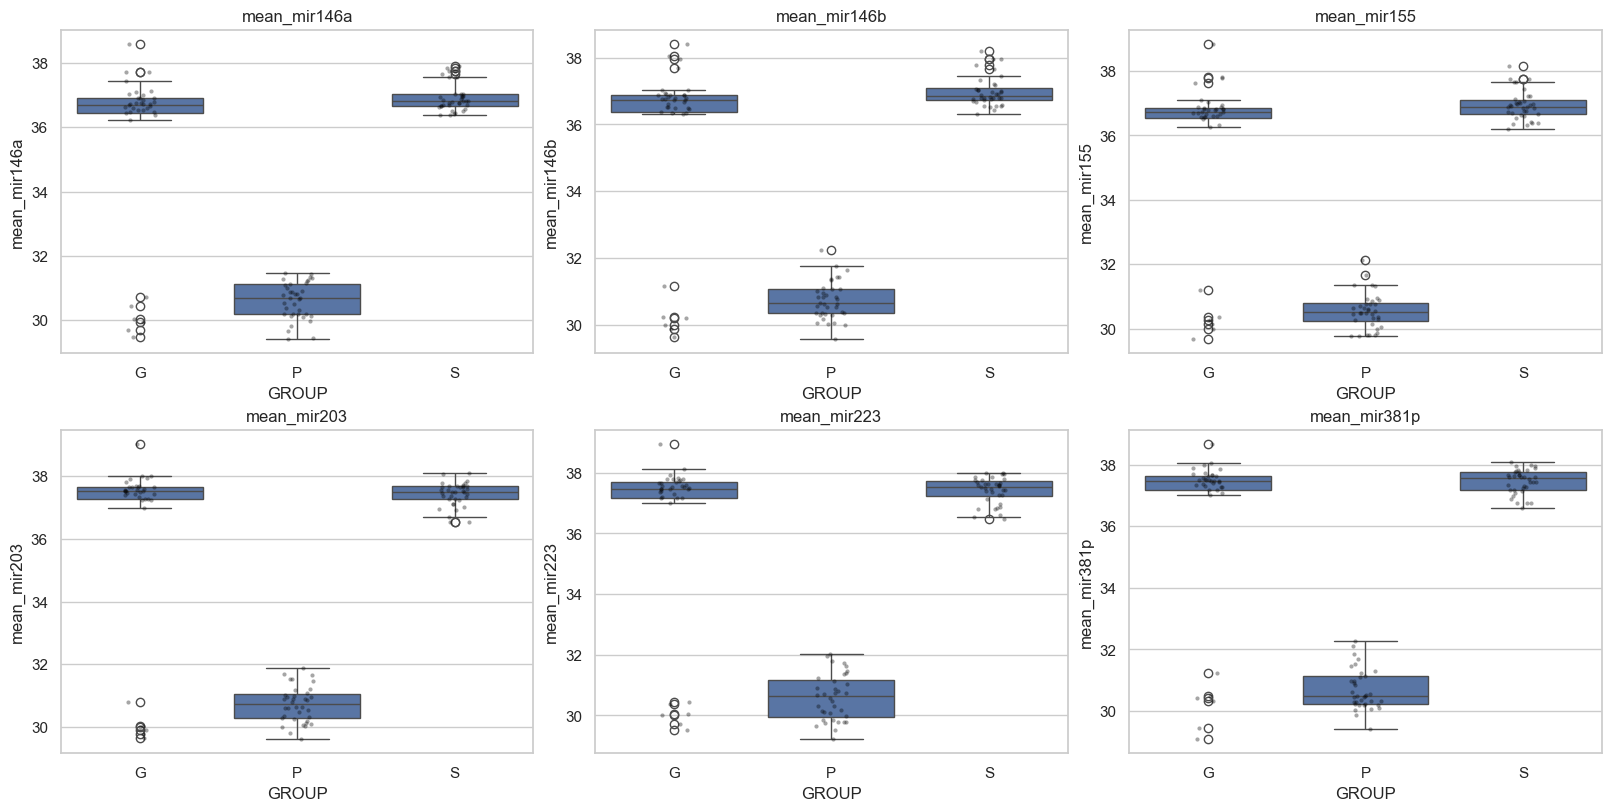

In [40]:

# EDA visualizations
fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
for ax, col in zip(axes.ravel(), miRNA_cols):
    sns.boxplot(data=df, x='GROUP', y=col, ax=ax)
    sns.stripplot(data=df, x='GROUP', y=col, color='black', alpha=0.35, size=3, ax=ax)
    ax.set_title(col)
plt.savefig(OUTPUT_DIR/'eda_miRNA_ct_boxplots.png', dpi=180)
plt.show()


In [41]:

# Task-wise inferential tests (primary: Mann-Whitney; secondary: Welch t-test)
tasks = {
    'Task1_S_vs_G': ('S','G'),
    'Task2_G_vs_P': ('G','P'),
    'Task3_S_vs_P': ('S','P'),
}

test_rows = []
for task_name, (g1, g2) in tasks.items():
    sub = df[df['GROUP'].isin([g1,g2])].copy()
    for marker in miRNA_cols + dct_cols + [ref_col, 'global_mean_ct_all7_proxy', 'global_mean_ct_miRNA_only_proxy']:
        x = sub.loc[sub['GROUP']==g1, marker].dropna()
        y = sub.loc[sub['GROUP']==g2, marker].dropna()
        mw = stats.mannwhitneyu(x, y, alternative='two-sided')
        tt = stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
        effect = (np.median(y) - np.median(x))
        test_rows.append({
            'Task':task_name, 'Group1':g1, 'Group2':g2,
            'Variable':marker,
            'n1':len(x), 'n2':len(y),
            'median_diff_g2_minus_g1':effect,
            'mw_p':mw.pvalue,
            'welch_p':tt.pvalue
        })

test_df = pd.DataFrame(test_rows)
# FDR within each task family
adj_parts = []
for task_name, part in test_df.groupby('Task'):
    p = part['mw_p'].values
    reject, q, *_ = multipletests(p, method='fdr_bh')
    part = part.copy()
    part['mw_q_fdr'] = q
    part['mw_reject_fdr05'] = reject
    adj_parts.append(part)

test_df = pd.concat(adj_parts, ignore_index=True)
test_df.to_csv(OUTPUT_DIR/'taskwise_inferential_tests.csv', index=False)
test_df.sort_values(['Task','mw_q_fdr']).head(20)


,Task,Group1,Group2,Variable,n1,n2,median_diff_g2_minus_g1,mw_p,welch_p,mw_q_fdr,mw_reject_fdr05
7,Task1_S_vs_G,S,G,dct_mir146b,36,36,-0.500000,1.199660e-04,4.260286e-05,1.480760e-03,True
8,Task1_S_vs_G,S,G,dct_mir155,36,36,-0.376667,1.974346e-04,8.432329e-05,1.480760e-03,True
6,Task1_S_vs_G,S,G,dct_mir146a,36,36,-0.523333,3.722724e-04,1.114121e-04,1.861362e-03,True
11,Task1_S_vs_G,S,G,dct_mir381p,36,36,-0.260000,9.283726e-04,9.597930e-04,3.481397e-03,True
1,Task1_S_vs_G,S,G,mean_mir146b,36,36,-0.103333,1.089671e-02,7.848487e-03,2.724177e-02,True
9,Task1_S_vs_G,S,G,dct_mir203,36,36,-0.283333,1.073982e-02,3.167065e-03,2.724177e-02,True
2,Task1_S_vs_G,S,G,mean_mir155,36,36,-0.170000,2.727808e-02,1.158497e-02,5.114641e-02,False
10,Task1_S_vs_G,S,G,dct_mir223,36,36,-0.105000,2.574830e-02,3.314918e-03,5.114641e-02,False
0,Task1_S_vs_G,S,G,mean_mir146a,36,36,-0.123333,5.920797e-02,1.034730e-02,9.867996e-02,False
13,Task1_S_vs_G,S,G,global_mean_ct_all7_proxy,36,36,-0.060238,1.857258e-01,1.976714e-02,2.532624e-01,False


In [42]:
# P1 hardening: explicit multiplicity families + assumption evidence + robust effect sizes/CIs for Section 9-10

multiplicity_family_registry = pd.DataFrame([
    {
        'Family_ID': 'F1',
        'Section': 'Section 9-10',
        'Family_Definition': 'Task-wise univariate contrasts across markers/derived variables',
        'Members': 'All tested variables within each fixed task separately',
        'Primary_Test': 'Mann-Whitney U',
        'Sensitivity_Test': 'Welch t-test',
        'Correction': 'BH-FDR applied within each task family',
    },
    {
        'Family_ID': 'F2',
        'Section': 'Section 12',
        'Family_Definition': 'Spearman marker-clinical correlation matrix',
        'Members': 'All marker x clinical pairs',
        'Primary_Test': 'Spearman rho',
        'Sensitivity_Test': 'None',
        'Correction': 'BH-FDR across full matrix',
    },
    {
        'Family_ID': 'F3',
        'Section': 'Section 12',
        'Family_Definition': 'Age-adjusted linear marker-clinical associations',
        'Members': 'All marker x clinical adjusted models',
        'Primary_Test': 'OLS coefficient test (clinical term)',
        'Sensitivity_Test': 'Residual/heteroskedasticity/influence diagnostics',
        'Correction': 'BH-FDR across adjusted family',
    },
])


def _cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    gt = np.sum(x[:, None] > y[None, :])
    lt = np.sum(x[:, None] < y[None, :])
    return (gt - lt) / (len(x) * len(y))


def _bootstrap_ci_2sample(x, y, stat_fn, n_boot=1000, seed=42, alpha=0.05):
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    vals = []
    for _ in range(n_boot):
        xb = x[rng.integers(0, len(x), len(x))]
        yb = y[rng.integers(0, len(y), len(y))]
        vals.append(stat_fn(xb, yb))
    lo = float(np.quantile(vals, alpha / 2))
    hi = float(np.quantile(vals, 1 - alpha / 2))
    med = float(np.median(vals))
    return med, lo, hi


assumption_effect_rows = []
family_vars = miRNA_cols + dct_cols + [ref_col, 'global_mean_ct_all7_proxy', 'global_mean_ct_miRNA_only_proxy']
for task_name, (g1, g2) in tasks.items():
    sub = df[df['GROUP'].isin([g1, g2])].copy()
    for v in family_vars:
        x = sub.loc[sub['GROUP'].eq(g1), v].dropna().values
        y = sub.loc[sub['GROUP'].eq(g2), v].dropna().values

        sh_p_x = stats.shapiro(x).pvalue if len(x) >= 3 else np.nan
        sh_p_y = stats.shapiro(y).pvalue if len(y) >= 3 else np.nan
        lev_p = stats.levene(x, y, center='median').pvalue if min(len(x), len(y)) >= 2 else np.nan

        cd = _cliffs_delta(x, y)
        cd_med, cd_lo, cd_hi = _bootstrap_ci_2sample(x, y, lambda a, b: _cliffs_delta(a, b), n_boot=1000, seed=42)
        md_med, md_lo, md_hi = _bootstrap_ci_2sample(x, y, lambda a, b: float(np.median(b) - np.median(a)), n_boot=1000, seed=42)

        assumption_effect_rows.append({
            'Task': task_name,
            'Variable': v,
            'n1': len(x),
            'n2': len(y),
            'Shapiro_p_group1': sh_p_x,
            'Shapiro_p_group2': sh_p_y,
            'Levene_p': lev_p,
            'Primary_inference_path': 'Mann-Whitney U',
            'Sensitivity_inference_path': 'Welch t-test',
            'Cliffs_delta': cd,
            'Cliffs_delta_boot_median': cd_med,
            'Cliffs_delta_ci95_low': cd_lo,
            'Cliffs_delta_ci95_high': cd_hi,
            'MedianDiff_boot_median_g2_minus_g1': md_med,
            'MedianDiff_ci95_low': md_lo,
            'MedianDiff_ci95_high': md_hi,
            'Sample_size_fragility': 'present' if min(len(x), len(y)) < 20 else 'none',
        })

assumption_effects_df = pd.DataFrame(assumption_effect_rows)

multiplicity_family_registry.to_csv(OUTPUT_DIR / 'multiplicity_family_registry.csv', index=False)
assumption_effects_df.to_csv(OUTPUT_DIR / 'taskwise_assumption_effects_ci.csv', index=False)

display(multiplicity_family_registry)
display(assumption_effects_df.head(20))


,Family_ID,Section,Family_Definition,Members,Primary_Test,Sensitivity_Test,Correction
0,F1,Section 9-10,Task-wise univariate contrasts across markers/...,All tested variables within each fixed task se...,Mann-Whitney U,Welch t-test,BH-FDR applied within each task family
1,F2,Section 12,Spearman marker-clinical correlation matrix,All marker x clinical pairs,Spearman rho,None,BH-FDR across full matrix
2,F3,Section 12,Age-adjusted linear marker-clinical associations,All marker x clinical adjusted models,OLS coefficient test (clinical term),Residual/heteroskedasticity/influence diagnostics,BH-FDR across adjusted family


,Task,Variable,n1,n2,Shapiro_p_group1,Shapiro_p_group2,Levene_p,Primary_inference_path,Sensitivity_inference_path,Cliffs_delta,Cliffs_delta_boot_median,Cliffs_delta_ci95_low,Cliffs_delta_ci95_high,MedianDiff_boot_median_g2_minus_g1,MedianDiff_ci95_low,MedianDiff_ci95_high,Sample_size_fragility
0,Task1_S_vs_G,mean_mir146a,36,36,4.492644e-04,1.729537e-08,0.011614,Mann-Whitney U,Welch t-test,0.259259,0.254630,-0.009298,0.512384,-0.119167,-0.318333,0.028417,none
1,Task1_S_vs_G,mean_mir146b,36,36,1.719029e-03,2.400019e-08,0.011508,Mann-Whitney U,Welch t-test,0.349537,0.352238,0.097068,0.599576,-0.151667,-0.415042,0.020042,none
2,Task1_S_vs_G,mean_mir155,36,36,8.070868e-02,2.015362e-08,0.015206,Mann-Whitney U,Welch t-test,0.303241,0.306327,0.036246,0.564063,-0.175000,-0.343417,-0.006667,none
3,Task1_S_vs_G,mean_mir203,36,36,7.060358e-02,3.308304e-09,0.014888,Mann-Whitney U,Welch t-test,0.033951,0.027006,-0.240760,0.265471,0.006667,-0.150000,0.165083,none
4,Task1_S_vs_G,mean_mir223,36,36,1.306749e-02,3.864181e-09,0.017201,Mann-Whitney U,Welch t-test,0.065586,0.057099,-0.216127,0.327951,-0.041667,-0.216667,0.145000,none
5,Task1_S_vs_G,mean_mir381p,36,36,1.751412e-01,4.413996e-09,0.018674,Mann-Whitney U,Welch t-test,0.108025,0.106481,-0.168248,0.355883,-0.096667,-0.273333,0.161750,none
6,Task1_S_vs_G,dct_mir146a,36,36,3.755533e-03,7.388659e-03,0.998380,Mann-Whitney U,Welch t-test,0.488426,0.491512,0.240548,0.700656,-0.538333,-1.040042,-0.211625,none
7,Task1_S_vs_G,dct_mir146b,36,36,2.050576e-01,2.868810e-02,0.795558,Mann-Whitney U,Welch t-test,0.527778,0.532407,0.275405,0.726890,-0.495833,-0.943417,-0.209667,none
8,Task1_S_vs_G,dct_mir155,36,36,8.760539e-01,5.501257e-02,0.509997,Mann-Whitney U,Welch t-test,0.510802,0.513889,0.257677,0.729958,-0.401667,-0.758375,-0.206583,none
9,Task1_S_vs_G,dct_mir203,36,36,4.675148e-01,1.810307e-06,0.019141,Mann-Whitney U,Welch t-test,0.350309,0.345293,0.081771,0.581829,-0.263333,-0.443542,-0.031583,none


### P1 hardening note — assumptions, multiplicity, and effect-size interpretation

- The **primary** inferential path for two-group contrasts is nonparametric (Mann–Whitney U).
- Welch tests are retained as **sensitivity** analyses, not primary adjudication, when parametric assumptions are fragile.
- Multiplicity control is defined by explicit families (`F1`–`F3`) and corrected with BH-FDR at the family level.
- Effect-size reporting now includes **Cliff’s $\delta$** and bootstrap 95% CIs for median differences.
- Non-significant findings are interpreted as “insufficient statistical evidence under this design,” not proof of no effect.


### Checkpoint — What was found and what happens next
1. **What was analyzed:** Descriptive and inferential group contrasts for fixed tasks.
2. **Main findings:** Ranked task-level differences are now quantified with FDR control and exported.
3. **What appears robust:** Variables surviving FDR correction per task merit follow-up modeling.
4. **What appears fragile/incomplete:** Univariate significance does not guarantee out-of-sample discrimination.
5. **Alternative explanations:** Clinical covariates and broader Ct structure can produce apparent biomarker effects.
6. **Next step:** Build leakage-safe binary classification workflows for each fixed task and model family.


## Section 11 — Reference-gene and normalization audit

This block explicitly audits `mean_GAPDH` behavior across groups and against covariates, then documents implications for normalization-dependent conclusions.

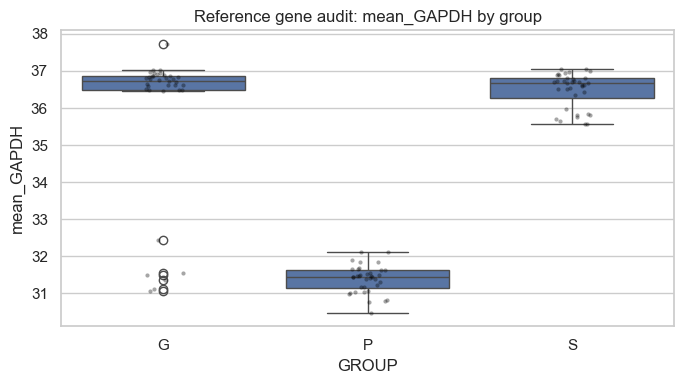

,GROUP,mean,std,median,min,max
0,G,35.905185,2.017755,36.741667,31.060000,37.730000
1,P,31.387870,0.373077,31.446667,30.476667,32.113333
2,S,36.492222,0.469061,36.680000,35.580000,37.060000


,Covariate,N_effective,Spearman_r,Spearman_p,Spearman_r_ci95_low,Spearman_r_ci95_high,Spearman_q_fdr
3,pocket_depth,108,-0.618685,9.642179e-13,-0.723116,-0.486602,5.785307e-12
4,bleeding_on_probing,108,-0.565964,1.736332e-10,-0.681996,-0.422138,5.208996e-10
0,AGE,108,-0.540898,1.510457e-09,-0.662186,-0.391992,3.020915e-09
1,plaque_index,108,-0.523345,6.201956e-09,-0.648211,-0.371069,9.302934e-09
2,gingival_index,108,-0.472237,2.472531e-07,-0.607039,-0.311018,2.967037e-07
5,number_of_missing_teeth,108,-0.326518,5.630306e-04,-0.485533,-0.146590,5.630306e-04


,Metric,Value
0,Kruskal-Wallis p (GROUP effect on GAPDH),6.547710e-14
1,One-way ANOVA p (GROUP effect on GAPDH),1.248398e-35


In [43]:
# GAPDH audit: group differences and associations with demographics/clinical variables
gapdh_summary = df.groupby('GROUP', observed=False)['mean_GAPDH'].agg(['mean','std','median','min','max']).reset_index()

# Group comparison (nonparametric primary + Welch sensitivity)
g_gapdh = [df.loc[df['GROUP'] == g, 'mean_GAPDH'].dropna().values for g in ['S','G','P']]
kw_stat, kw_p = stats.kruskal(*g_gapdh)
anova_stat, anova_p = stats.f_oneway(*g_gapdh)

# GAPDH correlation family with FDR and uncertainty
gapdh_associations = []
for cov in ['AGE', 'plaque_index', 'gingival_index', 'pocket_depth', 'bleeding_on_probing', 'number_of_missing_teeth']:
    r, p = stats.spearmanr(df['mean_GAPDH'], df[cov], nan_policy='omit')
    n_eff = int(df[['mean_GAPDH', cov]].dropna().shape[0])
    if pd.isna(r) or abs(r) >= 1 or n_eff <= 3:
        ci_low, ci_high = np.nan, np.nan
    else:
        z = np.arctanh(r)
        se = 1 / np.sqrt(n_eff - 3)
        zcrit = stats.norm.ppf(0.975)
        lo, hi = z - zcrit * se, z + zcrit * se
        ci_low, ci_high = float(np.tanh(lo)), float(np.tanh(hi))
    gapdh_associations.append({
        'Covariate': cov,
        'N_effective': n_eff,
        'Spearman_r': float(r),
        'Spearman_p': float(p),
        'Spearman_r_ci95_low': ci_low,
        'Spearman_r_ci95_high': ci_high,
    })
gapdh_assoc_df = pd.DataFrame(gapdh_associations)
gapdh_assoc_df['Spearman_q_fdr'] = multipletests(gapdh_assoc_df['Spearman_p'], method='fdr_bh')[1]

gapdh_audit_summary = pd.DataFrame([
    {'Metric': 'Kruskal-Wallis p (GROUP effect on GAPDH)', 'Value': kw_p},
    {'Metric': 'One-way ANOVA p (GROUP effect on GAPDH)', 'Value': anova_p},
])

# Save and visualize
gapdh_summary.to_csv(OUTPUT_DIR / 'gapdh_group_summary.csv', index=False)
gapdh_assoc_df.to_csv(OUTPUT_DIR / 'gapdh_covariate_associations.csv', index=False)
gapdh_audit_summary.to_csv(OUTPUT_DIR / 'gapdh_audit_tests.csv', index=False)

plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='GROUP', y='mean_GAPDH')
sns.stripplot(data=df, x='GROUP', y='mean_GAPDH', color='black', alpha=0.35, size=3)
plt.title('Reference gene audit: mean_GAPDH by group')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gapdh_group_distribution.png', dpi=180)
plt.show()

display(gapdh_summary)
display(gapdh_assoc_df.sort_values('Spearman_q_fdr'))
display(gapdh_audit_summary)


In [44]:
# P1 hardening: GAPDH assumption evidence and uncertainty interpretation

gapdh_assumption_rows = []
gapdh_groups_named = {g: df.loc[df['GROUP'].eq(g), 'mean_GAPDH'].dropna().values for g in ['S', 'G', 'P']}

for g, arr in gapdh_groups_named.items():
    sh_p = stats.shapiro(arr).pvalue if len(arr) >= 3 else np.nan
    gapdh_assumption_rows.append({'Group': g, 'N': len(arr), 'Shapiro_p': sh_p})

lev_p_gapdh = stats.levene(
    gapdh_groups_named['S'],
    gapdh_groups_named['G'],
    gapdh_groups_named['P'],
    center='median'
).pvalue

ss_between = sum(
    len(arr) * (np.mean(arr) - np.mean(np.concatenate(list(gapdh_groups_named.values())))) ** 2
    for arr in gapdh_groups_named.values()
)
ss_total = sum(
    np.sum((arr - np.mean(np.concatenate(list(gapdh_groups_named.values())))) ** 2)
    for arr in gapdh_groups_named.values()
)
eta_sq = ss_between / ss_total if ss_total > 0 else np.nan

gapdh_assumption_df = pd.DataFrame(gapdh_assumption_rows)
gapdh_assumption_df['Levene_p_all_groups'] = lev_p_gapdh
gapdh_assumption_df['ANOVA_eta_sq'] = eta_sq

gapdh_assumption_df.to_csv(OUTPUT_DIR / 'gapdh_assumption_evidence.csv', index=False)
display(gapdh_assumption_df)

print('Interpretation: Kruskal-Wallis remains primary for group effect if normality/variance assumptions are weak; ANOVA treated as sensitivity only.')


,Group,N,Shapiro_p,Levene_p_all_groups,ANOVA_eta_sq
0,S,36,2.086474e-04,0.012487,0.783644
1,G,36,3.898801e-09,0.012487,0.783644
2,P,36,6.476239e-01,0.012487,0.783644


Interpretation: Kruskal-Wallis remains primary for group effect if normality/variance assumptions are weak; ANOVA treated as sensitivity only.


## Section 12 — Clinical correlation analyses

This block reports Spearman correlations between miRNA-derived variables and clinical variables, plus age-adjusted associations using linear models.

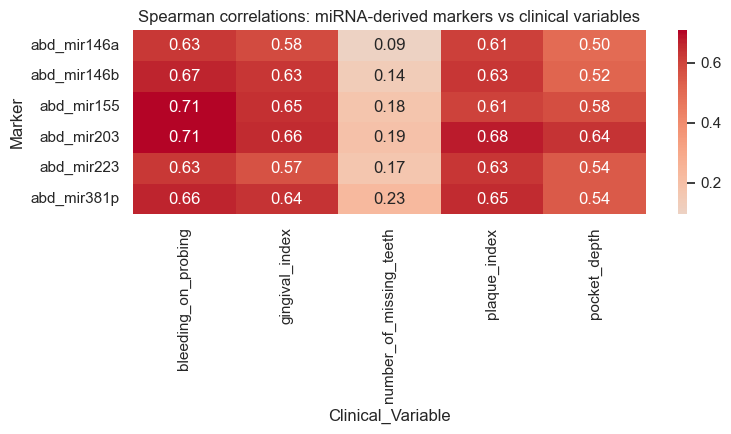

,Marker,Clinical_Variable,Spearman_r,Spearman_p,Spearman_q_fdr,Reject_fdr05
13,abd_mir155,bleeding_on_probing,0.705897,1.443956e-17,2.165935e-16,True
18,abd_mir203,bleeding_on_probing,0.708284,1.006352e-17,2.165935e-16,True
15,abd_mir203,plaque_index,0.675693,1.039496e-15,1.039496e-14,True
8,abd_mir146b,bleeding_on_probing,0.666382,3.515082e-15,2.636311e-14,True
28,abd_mir381p,bleeding_on_probing,0.663248,5.245417e-15,3.147250e-14,True
16,abd_mir203,gingival_index,0.657349,1.100126e-14,5.500631e-14,True
25,abd_mir381p,plaque_index,0.653033,1.871778e-14,8.021908e-14,True
11,abd_mir155,gingival_index,0.645670,4.545243e-14,1.704466e-13,True
26,abd_mir381p,gingival_index,0.636654,1.304214e-13,3.958093e-13,True
17,abd_mir203,pocket_depth,0.636553,1.319364e-13,3.958093e-13,True


,Marker,Clinical_Variable,Beta_clinical_adj_age,P_clinical_adj_age,N,P_q_fdr,Reject_fdr05
13,abd_mir155,bleeding_on_probing,0.019468,2.505165e-13,108,7.515495e-12,True
15,abd_mir203,plaque_index,0.781095,3.298651e-11,108,3.298651e-10,True
17,abd_mir203,pocket_depth,0.647328,2.385522e-11,108,3.298651e-10,True
11,abd_mir155,gingival_index,0.741432,6.041196e-11,108,4.530897e-10,True
25,abd_mir381p,plaque_index,0.805224,1.373903e-10,108,8.243416e-10,True
20,abd_mir223,plaque_index,0.823882,1.897938e-10,108,9.210756e-10,True
12,abd_mir155,pocket_depth,0.515522,2.149176e-10,108,9.210756e-10,True
6,abd_mir146b,gingival_index,0.754668,2.816314e-10,108,1.056118e-09,True
8,abd_mir146b,bleeding_on_probing,0.017899,5.401192e-10,108,1.800397e-09,True
5,abd_mir146b,plaque_index,0.639041,7.670119e-10,108,2.301036e-09,True


In [45]:
import statsmodels.api as sm

clinical_vars = ['plaque_index', 'gingival_index', 'pocket_depth', 'bleeding_on_probing', 'number_of_missing_teeth']
marker_vars = [c for c in df.columns if c.startswith('abd_mir')]

# Spearman correlation matrix (markers x clinical)
corr_rows = []
for m in marker_vars:
    for c in clinical_vars:
        r, p = stats.spearmanr(df[m], df[c], nan_policy='omit')
        corr_rows.append({'Marker': m, 'Clinical_Variable': c, 'Spearman_r': r, 'Spearman_p': p})
clinical_corr_df = pd.DataFrame(corr_rows)

# FDR correction across this family
rej, qvals, *_ = multipletests(clinical_corr_df['Spearman_p'].values, method='fdr_bh')
clinical_corr_df['Spearman_q_fdr'] = qvals
clinical_corr_df['Reject_fdr05'] = rej

# Age-adjusted linear associations (exploratory)
adj_rows = []
for m in marker_vars:
    for c in clinical_vars:
        temp = df[[m, c, 'AGE']].dropna()
        X = sm.add_constant(temp[['AGE', c]])
        y = temp[m]
        model = sm.OLS(y, X).fit()
        adj_rows.append({
            'Marker': m,
            'Clinical_Variable': c,
            'Beta_clinical_adj_age': model.params[c],
            'P_clinical_adj_age': model.pvalues[c],
            'N': len(temp),
        })
clinical_adj_df = pd.DataFrame(adj_rows)
rej2, qvals2, *_ = multipletests(clinical_adj_df['P_clinical_adj_age'].values, method='fdr_bh')
clinical_adj_df['P_q_fdr'] = qvals2
clinical_adj_df['Reject_fdr05'] = rej2

clinical_corr_df.to_csv(OUTPUT_DIR / 'clinical_correlations_spearman.csv', index=False)
clinical_adj_df.to_csv(OUTPUT_DIR / 'clinical_correlations_age_adjusted.csv', index=False)

heat = clinical_corr_df.pivot(index='Marker', columns='Clinical_Variable', values='Spearman_r')
plt.figure(figsize=(8,4.5))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Spearman correlations: miRNA-derived markers vs clinical variables')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'clinical_correlation_heatmap.png', dpi=180)
plt.show()

display(clinical_corr_df.sort_values('Spearman_q_fdr').head(15))
display(clinical_adj_df.sort_values('P_q_fdr').head(15))


In [46]:
# P1 hardening: adjusted-model diagnostics, CI extraction, collinearity/linearity checks, and explicit listwise-deletion implications
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf

# --- Adjusted model diagnostics ---
diag_rows = []
for m in marker_vars:
    for c in clinical_vars:
        temp = df[[m, c, 'AGE']].dropna()
        X = sm.add_constant(temp[['AGE', c]])
        y = temp[m]
        fit = sm.OLS(y, X).fit()

        resid = fit.resid
        exog = fit.model.exog
        sh_p = stats.shapiro(resid).pvalue if len(resid) <= 5000 else np.nan
        bp_stat, bp_p, _, _ = het_breuschpagan(resid, exog)
        infl = fit.get_influence()
        cooks = infl.cooks_distance[0]
        cook_thr = 4 / len(temp)

        # Collinearity (AGE + clinical predictor)
        vif_vals = [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]
        max_vif = float(np.max(vif_vals)) if len(vif_vals) else np.nan

        # Functional-form sensitivity (quadratic age/clinical terms)
        fit_age_quad = smf.ols(f"{m} ~ AGE + I(AGE**2) + {c}", data=temp).fit()
        fit_clin_quad = smf.ols(f"{m} ~ AGE + {c} + I({c}**2)", data=temp).fit()
        age_quad_delta_aic = float(fit.aic - fit_age_quad.aic)
        clin_quad_delta_aic = float(fit.aic - fit_clin_quad.aic)

        ci_low, ci_high = fit.conf_int().loc[c, 0], fit.conf_int().loc[c, 1]
        assumption_ok = (
            (pd.isna(sh_p) or sh_p > 0.05)
            and (bp_p > 0.05)
            and (np.mean(cooks > cook_thr) <= 0.05)
            and (max_vif < 5)
        )

        diag_rows.append({
            'Marker': m,
            'Clinical_Variable': c,
            'N': len(temp),
            'Beta_clinical_adj_age': fit.params[c],
            'Beta_ci95_low': ci_low,
            'Beta_ci95_high': ci_high,
            'P_clinical_adj_age': fit.pvalues[c],
            'Shapiro_resid_p': sh_p,
            'BreuschPagan_p': bp_p,
            'Max_CooksD': float(np.max(cooks)),
            'Frac_CooksD_gt_4_over_n': float(np.mean(cooks > cook_thr)),
            'Max_VIF_nonconst': max_vif,
            'Age_quad_delta_AIC': age_quad_delta_aic,
            'Clinical_quad_delta_AIC': clin_quad_delta_aic,
            'Assumption_flag': 'pass' if assumption_ok else 'review',
            'Inference_tier': 'tentative_adjusted' if assumption_ok else 'exploratory_adjusted',
        })

clinical_adj_diag_df = pd.DataFrame(diag_rows)
clinical_adj_diag_df['P_q_fdr'] = multipletests(clinical_adj_diag_df['P_clinical_adj_age'].values, method='fdr_bh')[1]

clinical_adj_diag_df.to_csv(OUTPUT_DIR / 'clinical_adjusted_ols_diagnostics.csv', index=False)

# --- Missingness/listwise deletion implications ---
analysis_sets = {
    'F1_univariate_taskwise': miRNA_cols + dct_cols + [ref_col, 'GROUP', 'global_mean_ct_all7_proxy', 'global_mean_ct_miRNA_only_proxy'],
    'F2_clinical_spearman': marker_vars + clinical_vars,
    'F3_clinical_adjusted_age': marker_vars + clinical_vars + ['AGE'],
    'classification_families': [c for c in (marker_vars + ['AGE', 'SEX', ref_col, 'global_mean_ct_all7_proxy', 'global_mean_ct_miRNA_only_proxy', 'GROUP']) if c in df.columns],
}

miss_rows = []
for fam, cols in analysis_sets.items():
    cc = df[cols].dropna()
    miss_rows.append({
        'Analysis_family': fam,
        'Rows_total': len(df),
        'Rows_complete_case': len(cc),
        'Complete_case_fraction': len(cc) / len(df),
        'Dropped_rows': len(df) - len(cc),
        'Listwise_deletion_impact': 'none' if len(cc) == len(df) else 'present',
        'Handling_rule': 'complete-case for correlation/adjusted models; in-fold imputation for classification',
    })

missingness_impact_df = pd.DataFrame(miss_rows)
missingness_impact_df.to_csv(OUTPUT_DIR / 'missingness_listwise_impact.csv', index=False)

display(clinical_adj_diag_df.sort_values(['Inference_tier', 'P_q_fdr']).head(20))
display(missingness_impact_df)


,Marker,Clinical_Variable,N,Beta_clinical_adj_age,Beta_ci95_low,Beta_ci95_high,P_clinical_adj_age,Shapiro_resid_p,BreuschPagan_p,Max_CooksD,Frac_CooksD_gt_4_over_n,Max_VIF_nonconst,Age_quad_delta_AIC,Clinical_quad_delta_AIC,Assumption_flag,Inference_tier,P_q_fdr
15,abd_mir203,plaque_index,108,0.781095,0.572162,0.990028,3.298651e-11,0.063097,0.000332,0.199581,0.055556,1.162436,0.016528,1.291464,review,exploratory_adjusted,3.298651e-10
17,abd_mir203,pocket_depth,108,0.647328,0.475690,0.818966,2.385522e-11,0.000002,0.460771,0.108248,0.083333,1.559635,-1.581432,3.874489,review,exploratory_adjusted,3.298651e-10
25,abd_mir381p,plaque_index,108,0.805224,0.581071,1.029377,1.373903e-10,0.002559,0.034111,0.192237,0.046296,1.162436,1.125812,2.195972,review,exploratory_adjusted,8.243416e-10
20,abd_mir223,plaque_index,108,0.823882,0.592385,1.055379,1.897938e-10,0.263946,0.000035,0.181146,0.055556,1.162436,-0.438421,2.118149,review,exploratory_adjusted,9.210756e-10
6,abd_mir146b,gingival_index,108,0.754668,0.540155,0.969180,2.816314e-10,0.635203,0.455259,0.334124,0.055556,1.158325,0.921004,4.310701,review,exploratory_adjusted,1.056118e-09
18,abd_mir203,bleeding_on_probing,108,0.020258,0.014255,0.026261,1.109637e-09,0.000004,0.299148,0.141459,0.037037,1.444924,0.192430,7.877961,review,exploratory_adjusted,2.829052e-09
28,abd_mir381p,bleeding_on_probing,108,0.020793,0.014357,0.027228,4.299931e-09,0.000424,0.066735,0.126129,0.046296,1.444924,1.305341,6.165559,review,exploratory_adjusted,9.922917e-09
26,abd_mir381p,gingival_index,108,0.863313,0.595380,1.131245,4.669516e-09,0.007479,0.003420,0.268132,0.055556,1.158325,2.113659,2.835138,review,exploratory_adjusted,1.000610e-08
16,abd_mir203,gingival_index,108,0.809983,0.556224,1.063742,6.186039e-09,0.001203,0.006345,0.220925,0.046296,1.158325,0.875183,2.337805,review,exploratory_adjusted,1.227457e-08
23,abd_mir223,bleeding_on_probing,108,0.020857,0.014165,0.027549,1.239795e-08,0.000228,0.166637,0.137323,0.037037,1.444924,-0.255183,0.715127,review,exploratory_adjusted,2.187874e-08


,Analysis_family,Rows_total,Rows_complete_case,Complete_case_fraction,Dropped_rows,Listwise_deletion_impact,Handling_rule
0,F1_univariate_taskwise,108,108,1.0,0,none,complete-case for correlation/adjusted models;...
1,F2_clinical_spearman,108,108,1.0,0,none,complete-case for correlation/adjusted models;...
2,F3_clinical_adjusted_age,108,108,1.0,0,none,complete-case for correlation/adjusted models;...
3,classification_families,108,108,1.0,0,none,complete-case for correlation/adjusted models;...


## Section 13-16 — Leakage-safe classification, panel comparison, confounding adjustment, and broader/global structure

**Leakage-safety method note (P0 remediation):**
- Any searched panel selection is performed within each outer-training fold only.
- Hyperparameter tuning remains inner-fold only.
- Reported discrimination metrics are computed from outer-fold out-of-fold (OOF) predictions.
- Searched panels are labeled exploratory (selection-affected) even when fold-contained.
- Primary threshold is pre-declared at 0.5 (no threshold optimization on evaluation outcomes).
- Threshold-sensitivity and calibration diagnostics, when shown, are computed from OOF predictions only and are descriptive (not used for model selection).

In [47]:
# Helper functions for leakage-safe nested CV evaluation
from itertools import combinations


def binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan
    return {
        'AUC': auc,
        'Accuracy': acc,
        'Sensitivity': sens,
        'Specificity': spec,
        'PPV': ppv,
        'NPV': npv,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
    }


def nested_oof_proba(X, y, preprocessor, selector_k=None, random_state=42):
    outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=random_state)

    oof_prob = np.zeros(len(y), dtype=float)

    for tr_idx, te_idx in outer.split(X, y):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr = y.iloc[tr_idx]

        steps = [('prep', preprocessor)]
        if selector_k is not None:
            steps.append(('select', SelectKBest(score_func=f_classif, k=selector_k)))
        steps.append(('clf', LogisticRegression(max_iter=5000, solver='liblinear')))
        pipe = Pipeline(steps)

        param_grid = {'clf__C': [0.1, 1, 10]}
        gs = GridSearchCV(pipe, param_grid=param_grid, cv=inner, scoring='roc_auc', n_jobs=1)
        gs.fit(X_tr, y_tr)
        oof_prob[te_idx] = gs.best_estimator_.predict_proba(X_te)[:, 1]

    return oof_prob


def nested_oof_small_panel_search(sub, y, abd_cols, random_state=42):
    """
    Leakage-safe searched panel evaluation:
    candidate ranking and panel search are done inside each outer-training fold.
    Returns OOF probabilities and fold-level selected panel metadata.
    """
    outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=random_state)

    oof_prob = np.zeros(len(y), dtype=float)
    fold_rows = []

    for fold_id, (tr_idx, te_idx) in enumerate(outer.split(sub, y), start=1):
        x_tr_full = sub.iloc[tr_idx].reset_index(drop=True)
        y_tr = y.iloc[tr_idx].reset_index(drop=True)
        x_te_full = sub.iloc[te_idx]

        marker_auc = []
        for marker in abd_cols:
            x_m = x_tr_full[marker]
            if x_m.nunique(dropna=True) < 2:
                continue
            try:
                auc = roc_auc_score(y_tr, x_m)
                marker_auc.append((marker, max(auc, 1 - auc)))
            except Exception:
                continue

        if len(marker_auc) < 2:
            variances = x_tr_full[abd_cols].var().sort_values(ascending=False)
            top_markers = variances.index[:2].tolist()
        else:
            top_markers = [m for m, _ in sorted(marker_auc, key=lambda x: x[1], reverse=True)[:3]]

        candidate_pairs = list(combinations(top_markers, 2))
        if not candidate_pairs:
            candidate_pairs = [tuple(top_markers[:2])]

        best_pair = None
        best_score = -np.inf
        best_estimator = None

        for pair in candidate_pairs:
            pair = list(pair)
            pre = ColumnTransformer([
                ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), pair)
            ])
            pipe = Pipeline([
                ('prep', pre),
                ('clf', LogisticRegression(max_iter=5000, solver='liblinear')),
            ])
            gs = GridSearchCV(
                pipe,
                param_grid={'clf__C': [0.1, 1, 10]},
                cv=inner,
                scoring='roc_auc',
                n_jobs=1,
            )
            gs.fit(x_tr_full[pair], y_tr)

            if gs.best_score_ > best_score:
                best_score = gs.best_score_
                best_pair = pair
                best_estimator = gs.best_estimator_

        oof_prob[te_idx] = best_estimator.predict_proba(x_te_full[best_pair])[:, 1]
        fold_rows.append({
            'Fold': fold_id,
            'Selected_Panel': '+'.join(best_pair),
            'InnerCV_BestAUC': float(best_score),
            'Candidate_Count': len(candidate_pairs),
        })

    return oof_prob, pd.DataFrame(fold_rows)


def evaluate_task_models(task_name, g1, g2):
    sub = df[df['GROUP'].isin([g1, g2])].copy().reset_index(drop=True)
    y = (sub['GROUP'] == g2).astype(int)

    abd_cols = [c for c in sub.columns if c.startswith('abd_mir')]
    proxy_cols = [c for c in ['global_mean_ct_all7_proxy', 'global_mean_ct_miRNA_only_proxy'] if c in sub.columns]

    results = []
    fold_selection_logs = []

    # 1) single-marker models (exploratory across markers)
    for marker in abd_cols:
        X = sub[[marker]]
        pre = ColumnTransformer([
            ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), [marker])
        ])
        probs = nested_oof_proba(X, y, preprocessor=pre, selector_k=None)
        m = binary_metrics(y, probs)
        m.update({
            'Task': task_name,
            'Model_Family': 'single_marker',
            'Model_Label': marker,
            'n': len(sub),
            'Model_Validity': 'Exploratory internal',
            'Claim_Ceiling': 'Exploratory',
        })
        results.append(m)

    # 2) small searched panels, fold-contained nested search
    panel_probs, panel_fold_log = nested_oof_small_panel_search(sub, y, abd_cols, random_state=42)
    panel_metrics = binary_metrics(y, panel_probs)
    panel_metrics.update({
        'Task': task_name,
        'Model_Family': 'small_panel_exploratory',
        'Model_Label': 'searched_top3_pairs_fold_contained',
        'n': len(sub),
        'Model_Validity': 'Exploratory (fold-contained search)',
        'Claim_Ceiling': 'Exploratory',
    })
    results.append(panel_metrics)

    panel_fold_log['Task'] = task_name
    fold_selection_logs.append(panel_fold_log)

    # 3) demographic-only
    dem = ['AGE', 'SEX']
    X = sub[dem]
    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), ['AGE']),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(drop='if_binary'))]), ['SEX'])
    ])
    probs = nested_oof_proba(X, y, preprocessor=pre, selector_k=None)
    m = binary_metrics(y, probs)
    m.update({
        'Task': task_name,
        'Model_Family': 'demographic_only',
        'Model_Label': 'AGE+SEX',
        'n': len(sub),
        'Model_Validity': 'Tentative internal',
        'Claim_Ceiling': 'Tentative',
    })
    results.append(m)

    # 4) biomarker+demographic, leakage-safe feature selection on training folds
    X = sub[abd_cols + dem]
    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), abd_cols + ['AGE']),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(drop='if_binary'))]), ['SEX'])
    ])
    k = min(5, len(abd_cols) + 1)
    probs = nested_oof_proba(X, y, preprocessor=pre, selector_k=k)
    m = binary_metrics(y, probs)
    m.update({
        'Task': task_name,
        'Model_Family': 'biomarker_plus_demographic',
        'Model_Label': f'ABD+AGE+SEX_select{k}',
        'n': len(sub),
        'Model_Validity': 'Tentative internal',
        'Claim_Ceiling': 'Tentative',
    })
    results.append(m)

    # 5) broader/global only
    X = sub[proxy_cols]
    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), proxy_cols)
    ])
    probs = nested_oof_proba(X, y, preprocessor=pre, selector_k=None)
    m = binary_metrics(y, probs)
    m.update({
        'Task': task_name,
        'Model_Family': 'broader_global_only',
        'Model_Label': '+'.join(proxy_cols),
        'n': len(sub),
        'Model_Validity': 'Tentative internal',
        'Claim_Ceiling': 'Tentative',
    })
    results.append(m)

    # 6) combined biomarker + broader/global + demographics
    all_cols = abd_cols + proxy_cols + dem
    X = sub[all_cols]
    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), abd_cols + proxy_cols + ['AGE']),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(drop='if_binary'))]), ['SEX'])
    ])
    k = min(7, len(abd_cols) + len(proxy_cols) + 1)
    probs = nested_oof_proba(X, y, preprocessor=pre, selector_k=k)
    m = binary_metrics(y, probs)
    m.update({
        'Task': task_name,
        'Model_Family': 'combined_model',
        'Model_Label': f'ABD+Proxy+Demo_select{k}',
        'n': len(sub),
        'Model_Validity': 'Tentative internal',
        'Claim_Ceiling': 'Tentative',
    })
    results.append(m)

    return pd.DataFrame(results), pd.concat(fold_selection_logs, ignore_index=True)


In [48]:
all_model_results = []
all_panel_logs = []
for task_name, (g1, g2) in tasks.items():
    res, panel_log = evaluate_task_models(task_name, g1, g2)
    all_model_results.append(res)
    all_panel_logs.append(panel_log)

model_results = pd.concat(all_model_results, ignore_index=True)
panel_search_log = pd.concat(all_panel_logs, ignore_index=True)

# Keep one searched-panel row per task (fold-contained search output)
model_results = model_results.drop_duplicates(subset=['Task', 'Model_Family', 'Model_Label']).reset_index(drop=True)

model_results.to_csv(OUTPUT_DIR / 'task_model_performance_nestedcv.csv', index=False)
panel_search_log.to_csv(OUTPUT_DIR / 'searched_panel_fold_selection_log.csv', index=False)

# Panel-selection stability summary (fold-contained provenance)
stab_rows = []
for task_name, part in panel_search_log.groupby('Task'):
    freq = part['Selected_Panel'].value_counts()
    p = freq / freq.sum()
    entropy = float(-(p * np.log2(p)).sum()) if len(p) > 0 else np.nan
    stab_rows.append({
        'Task': task_name,
        'Unique_Selected_Panels': int(freq.shape[0]),
        'Most_Frequent_Panel': freq.index[0] if len(freq) > 0 else np.nan,
        'Most_Frequent_Count': int(freq.iloc[0]) if len(freq) > 0 else 0,
        'Most_Frequent_Proportion': float(p.iloc[0]) if len(p) > 0 else np.nan,
        'Selection_Entropy_bits': entropy,
        'Interpretation': 'Lower entropy and higher top proportion indicate more stable fold-level panel selection.',
    })
panel_stability_df = pd.DataFrame(stab_rows)
panel_stability_df.to_csv(OUTPUT_DIR / 'searched_panel_selection_stability.csv', index=False)

display(model_results.sort_values(['Task', 'AUC'], ascending=[True, False]).head(30))
display(panel_search_log.head(15))
display(panel_stability_df)


,AUC,Accuracy,Sensitivity,Specificity,PPV,NPV,TN,FP,FN,TP,Task,Model_Family,Model_Label,n,Model_Validity,Claim_Ceiling
1,0.761574,0.666667,0.694444,0.638889,0.657895,0.676471,23,13,11,25,Task1_S_vs_G,single_marker,abd_mir146b,72,Exploratory internal,Exploratory
2,0.754630,0.694444,0.694444,0.694444,0.694444,0.694444,25,11,11,25,Task1_S_vs_G,single_marker,abd_mir155,72,Exploratory internal,Exploratory
0,0.734954,0.680556,0.694444,0.666667,0.675676,0.685714,24,12,11,25,Task1_S_vs_G,single_marker,abd_mir146a,72,Exploratory internal,Exploratory
10,0.732253,0.680556,0.666667,0.694444,0.685714,0.675676,25,11,12,24,Task1_S_vs_G,combined_model,ABD+Proxy+Demo_select7,72,Tentative internal,Tentative
8,0.730710,0.694444,0.694444,0.694444,0.694444,0.694444,25,11,11,25,Task1_S_vs_G,biomarker_plus_demographic,ABD+AGE+SEX_select5,72,Tentative internal,Tentative
5,0.721836,0.680556,0.583333,0.777778,0.724138,0.651163,28,8,15,21,Task1_S_vs_G,single_marker,abd_mir381p,72,Exploratory internal,Exploratory
6,0.702932,0.638889,0.666667,0.611111,0.631579,0.647059,22,14,12,24,Task1_S_vs_G,small_panel_exploratory,searched_top3_pairs_fold_contained,72,Exploratory (fold-contained search),Exploratory
3,0.664738,0.625000,0.500000,0.750000,0.666667,0.600000,27,9,18,18,Task1_S_vs_G,single_marker,abd_mir203,72,Exploratory internal,Exploratory
4,0.644290,0.625000,0.444444,0.805556,0.695652,0.591837,29,7,20,16,Task1_S_vs_G,single_marker,abd_mir223,72,Exploratory internal,Exploratory
7,0.623071,0.625000,0.750000,0.500000,0.600000,0.666667,18,18,9,27,Task1_S_vs_G,demographic_only,AGE+SEX,72,Tentative internal,Tentative


,Fold,Selected_Panel,InnerCV_BestAUC,Candidate_Count,Task
0,1,abd_mir155+abd_mir146b,0.740434,3,Task1_S_vs_G
1,2,abd_mir146b+abd_mir155,0.785714,3,Task1_S_vs_G
2,3,abd_mir381p+abd_mir146a,0.760204,3,Task1_S_vs_G
3,4,abd_mir155+abd_mir146a,0.776148,3,Task1_S_vs_G
4,5,abd_mir155+abd_mir146b,0.818240,3,Task1_S_vs_G
5,1,abd_mir203+abd_mir155,0.866071,3,Task2_G_vs_P
6,2,abd_mir203+abd_mir223,0.799107,3,Task2_G_vs_P
7,3,abd_mir223+abd_mir155,0.881378,3,Task2_G_vs_P
8,4,abd_mir381p+abd_mir223,0.832908,3,Task2_G_vs_P
9,5,abd_mir203+abd_mir155,0.866071,3,Task2_G_vs_P


,Task,Unique_Selected_Panels,Most_Frequent_Panel,Most_Frequent_Count,Most_Frequent_Proportion,Selection_Entropy_bits,Interpretation
0,Task1_S_vs_G,4,abd_mir155+abd_mir146b,2,0.4,1.921928,Lower entropy and higher top proportion indica...
1,Task2_G_vs_P,4,abd_mir203+abd_mir155,2,0.4,1.921928,Lower entropy and higher top proportion indica...
2,Task3_S_vs_P,2,abd_mir203+abd_mir155,4,0.8,0.721928,Lower entropy and higher top proportion indica...


In [49]:
# P1 hardening: explicit multiplicity family for model-comparison interpretations
model_comparison_family_registry = pd.DataFrame([
    {
        'Family_ID': 'M1',
        'Section': 'Section 13-16',
        'Family_Definition': 'Task-wise model-family discrimination comparisons',
        'Members': 'single_marker, small_panel_exploratory, demographic_only, biomarker_plus_demographic, broader_global_only, combined_model within each fixed task',
        'Primary_Metric': 'AUC from OOF predictions',
        'Correction_or_Ceiling': 'Exploratory ceiling for cross-family superiority claims unless explicitly corrected',
    },
    {
        'Family_ID': 'M2',
        'Section': 'Section 17-18',
        'Family_Definition': 'Pre-specified family robustness summaries',
        'Members': 'single_marker_prespecified, demographic_only, broader_global_only, combined_model by task',
        'Primary_Metric': 'Bootstrap AUC CI and permutation p-values',
        'Correction_or_Ceiling': 'Family interpreted as uncertainty characterization, not confirmatory superiority testing',
    },
])
model_comparison_family_registry.to_csv(OUTPUT_DIR / 'model_comparison_family_registry.csv', index=False)
display(model_comparison_family_registry)


,Family_ID,Section,Family_Definition,Members,Primary_Metric,Correction_or_Ceiling
0,M1,Section 13-16,Task-wise model-family discrimination comparisons,"single_marker, small_panel_exploratory, demogr...",AUC from OOF predictions,Exploratory ceiling for cross-family superiori...
1,M2,Section 17-18,Pre-specified family robustness summaries,"single_marker_prespecified, demographic_only, ...",Bootstrap AUC CI and permutation p-values,Family interpreted as uncertainty characteriza...


In [50]:
# Threshold-sensitivity + calibration diagnostics from OOF predictions only (descriptive, non-selective)
from sklearn.metrics import brier_score_loss

def _ece_binary(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ids = np.digitize(y_prob, bins[1:-1], right=True)
    ece = 0.0
    n = len(y_true)
    for b in range(n_bins):
        m = ids == b
        if np.sum(m) == 0:
            continue
        acc = np.mean(y_true[m])
        conf = np.mean(y_prob[m])
        ece += (np.sum(m) / n) * abs(acc - conf)
    return float(ece)

threshold_grid = [0.3, 0.5, 0.7]
sensitivity_rows = []
calibration_rows = []

for task_name, (g1, g2) in tasks.items():
    sub = df[df['GROUP'].isin([g1, g2])].copy().reset_index(drop=True)
    y = (sub['GROUP'] == g2).astype(int)

    abd_cols_local = [c for c in sub.columns if c.startswith('abd_mir')]
    proxy_cols_local = [c for c in ['global_mean_ct_all7_proxy', 'global_mean_ct_miRNA_only_proxy'] if c in sub.columns]
    dem = ['AGE', 'SEX']

    family_specs = []

    # demographic_only
    X_dem = sub[dem]
    pre_dem = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), ['AGE']),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(drop='if_binary'))]), ['SEX'])
    ])
    family_specs.append(('demographic_only', 'AGE+SEX', X_dem, pre_dem, None))

    # broader_global_only
    X_glob = sub[proxy_cols_local]
    pre_glob = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), proxy_cols_local)
    ])
    family_specs.append(('broader_global_only', '+'.join(proxy_cols_local), X_glob, pre_glob, None))

    # combined_model
    all_cols = abd_cols_local + proxy_cols_local + dem
    X_comb = sub[all_cols]
    pre_comb = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), abd_cols_local + proxy_cols_local + ['AGE']),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(drop='if_binary'))]), ['SEX'])
    ])
    k_comb = min(7, len(abd_cols_local) + len(proxy_cols_local) + 1)
    family_specs.append(('combined_model', f'ABD+Proxy+Demo_select{k_comb}', X_comb, pre_comb, k_comb))

    # searched panel exploratory (still exploratory, but fold-contained and OOF)
    sp_prob, _ = nested_oof_small_panel_search(sub, y, abd_cols_local, random_state=42)
    for th in threshold_grid:
        m = binary_metrics(y, sp_prob, threshold=th)
        sensitivity_rows.append({
            'Task': task_name,
            'Model_Family': 'small_panel_exploratory',
            'Model_Label': 'searched_top3_pairs_fold_contained',
            'Threshold': th,
            **m,
        })
    calibration_rows.append({
        'Task': task_name,
        'Model_Family': 'small_panel_exploratory',
        'Model_Label': 'searched_top3_pairs_fold_contained',
        'AUC_oof': float(roc_auc_score(y, sp_prob)),
        'Brier_oof': float(brier_score_loss(y, sp_prob)),
        'ECE10_oof': _ece_binary(y.values, sp_prob, n_bins=10),
        'Calibration_note': 'Descriptive OOF calibration; not used for selection/tuning.',
    })

    # fixed families
    for fam, label, X_use, pre_use, k_use in family_specs:
        prob = nested_oof_proba(X_use, y, preprocessor=pre_use, selector_k=k_use, random_state=42)
        for th in threshold_grid:
            m = binary_metrics(y, prob, threshold=th)
            sensitivity_rows.append({
                'Task': task_name,
                'Model_Family': fam,
                'Model_Label': label,
                'Threshold': th,
                **m,
            })
        calibration_rows.append({
            'Task': task_name,
            'Model_Family': fam,
            'Model_Label': label,
            'AUC_oof': float(roc_auc_score(y, prob)),
            'Brier_oof': float(brier_score_loss(y, prob)),
            'ECE10_oof': _ece_binary(y.values, prob, n_bins=10),
            'Calibration_note': 'Descriptive OOF calibration; not used for selection/tuning.',
        })

threshold_sensitivity_df = pd.DataFrame(sensitivity_rows)
calibration_df = pd.DataFrame(calibration_rows)

threshold_sensitivity_df.to_csv(OUTPUT_DIR / 'threshold_sensitivity_oof.csv', index=False)
calibration_df.to_csv(OUTPUT_DIR / 'calibration_oof_diagnostics.csv', index=False)

display(threshold_sensitivity_df.head(20))
display(calibration_df.sort_values(['Task', 'AUC_oof'], ascending=[True, False]))


,Task,Model_Family,Model_Label,Threshold,AUC,Accuracy,Sensitivity,Specificity,PPV,NPV,TN,FP,FN,TP
0,Task1_S_vs_G,small_panel_exploratory,searched_top3_pairs_fold_contained,0.3,0.702932,0.611111,0.833333,0.388889,0.576923,0.700000,14,22,6,30
1,Task1_S_vs_G,small_panel_exploratory,searched_top3_pairs_fold_contained,0.5,0.702932,0.638889,0.666667,0.611111,0.631579,0.647059,22,14,12,24
2,Task1_S_vs_G,small_panel_exploratory,searched_top3_pairs_fold_contained,0.7,0.702932,0.597222,0.222222,0.972222,0.888889,0.555556,35,1,28,8
3,Task1_S_vs_G,demographic_only,AGE+SEX,0.3,0.623071,0.541667,1.000000,0.083333,0.521739,1.000000,3,33,0,36
4,Task1_S_vs_G,demographic_only,AGE+SEX,0.5,0.623071,0.625000,0.750000,0.500000,0.600000,0.666667,18,18,9,27
5,Task1_S_vs_G,demographic_only,AGE+SEX,0.7,0.623071,0.500000,0.000000,1.000000,NaN,0.500000,36,0,36,0
6,Task1_S_vs_G,broader_global_only,global_mean_ct_all7_proxy+global_mean_ct_miRNA...,0.3,0.596451,0.486111,0.972222,0.000000,0.492958,0.000000,0,36,1,35
7,Task1_S_vs_G,broader_global_only,global_mean_ct_all7_proxy+global_mean_ct_miRNA...,0.5,0.596451,0.583333,0.194444,0.972222,0.875000,0.546875,35,1,29,7
8,Task1_S_vs_G,broader_global_only,global_mean_ct_all7_proxy+global_mean_ct_miRNA...,0.7,0.596451,0.583333,0.166667,1.000000,1.000000,0.545455,36,0,30,6
9,Task1_S_vs_G,combined_model,ABD+Proxy+Demo_select7,0.3,0.732253,0.597222,0.916667,0.277778,0.559322,0.769231,10,26,3,33


,Task,Model_Family,Model_Label,AUC_oof,Brier_oof,ECE10_oof,Calibration_note
3,Task1_S_vs_G,combined_model,ABD+Proxy+Demo_select7,0.732253,0.204361,0.073811,Descriptive OOF calibration; not used for sele...
0,Task1_S_vs_G,small_panel_exploratory,searched_top3_pairs_fold_contained,0.702932,0.215994,0.055549,Descriptive OOF calibration; not used for sele...
1,Task1_S_vs_G,demographic_only,AGE+SEX,0.623071,0.232943,0.103394,Descriptive OOF calibration; not used for sele...
2,Task1_S_vs_G,broader_global_only,global_mean_ct_all7_proxy+global_mean_ct_miRNA...,0.596451,0.229988,0.031056,Descriptive OOF calibration; not used for sele...
7,Task2_G_vs_P,combined_model,ABD+Proxy+Demo_select7,0.997685,0.030760,0.054358,Descriptive OOF calibration; not used for sele...
5,Task2_G_vs_P,demographic_only,AGE+SEX,0.974151,0.087936,0.146963,Descriptive OOF calibration; not used for sele...
6,Task2_G_vs_P,broader_global_only,global_mean_ct_all7_proxy+global_mean_ct_miRNA...,0.853395,0.097385,0.186674,Descriptive OOF calibration; not used for sele...
4,Task2_G_vs_P,small_panel_exploratory,searched_top3_pairs_fold_contained,0.792438,0.182268,0.238013,Descriptive OOF calibration; not used for sele...
10,Task3_S_vs_P,broader_global_only,global_mean_ct_all7_proxy+global_mean_ct_miRNA...,1.000000,0.023798,0.152730,Descriptive OOF calibration; not used for sele...
11,Task3_S_vs_P,combined_model,ABD+Proxy+Demo_select7,1.000000,0.016618,0.103262,Descriptive OOF calibration; not used for sele...


In [51]:

# Section 14 explicitly: single-marker vs small-panel comparison
single_vs_panel = model_results[model_results['Model_Family'].isin(['single_marker','small_panel_exploratory'])].copy()
single_vs_panel_summary = (
    single_vs_panel
    .groupby(['Task','Model_Family'])['AUC']
    .agg(['max','median','mean','count'])
    .reset_index()
)
single_vs_panel_summary.to_csv(OUTPUT_DIR/'single_vs_panel_summary.csv', index=False)
single_vs_panel_summary


,Task,Model_Family,max,median,mean,count
0,Task1_S_vs_G,single_marker,0.761574,0.728395,0.713670,6
1,Task1_S_vs_G,small_panel_exploratory,0.702932,0.702932,0.702932,1
2,Task2_G_vs_P,single_marker,0.841049,0.812114,0.798225,6
3,Task2_G_vs_P,small_panel_exploratory,0.792438,0.792438,0.792438,1
4,Task3_S_vs_P,single_marker,0.992284,0.945602,0.950103,6
5,Task3_S_vs_P,small_panel_exploratory,0.969907,0.969907,0.969907,1


In [52]:

# Section 15-16 focused comparisons for confounding and broader/global effects
focused = model_results[model_results['Model_Family'].isin([
    'demographic_only','biomarker_plus_demographic','broader_global_only','combined_model'
])].sort_values(['Task','AUC'], ascending=[True,False])
focused.to_csv(OUTPUT_DIR/'confounding_and_broader_comparisons.csv', index=False)
focused


,AUC,Accuracy,Sensitivity,Specificity,PPV,NPV,TN,FP,FN,TP,Task,Model_Family,Model_Label,n,Model_Validity,Claim_Ceiling
10,0.732253,0.680556,0.666667,0.694444,0.685714,0.675676,25,11,12,24,Task1_S_vs_G,combined_model,ABD+Proxy+Demo_select7,72,Tentative internal,Tentative
8,0.730710,0.694444,0.694444,0.694444,0.694444,0.694444,25,11,11,25,Task1_S_vs_G,biomarker_plus_demographic,ABD+AGE+SEX_select5,72,Tentative internal,Tentative
7,0.623071,0.625000,0.750000,0.500000,0.600000,0.666667,18,18,9,27,Task1_S_vs_G,demographic_only,AGE+SEX,72,Tentative internal,Tentative
9,0.596451,0.583333,0.194444,0.972222,0.875000,0.546875,35,1,29,7,Task1_S_vs_G,broader_global_only,global_mean_ct_all7_proxy+global_mean_ct_miRNA...,72,Tentative internal,Tentative
21,0.997685,0.958333,1.000000,0.916667,0.923077,1.000000,33,3,0,36,Task2_G_vs_P,combined_model,ABD+Proxy+Demo_select7,72,Tentative internal,Tentative
18,0.974151,0.930556,0.916667,0.944444,0.942857,0.918919,34,2,3,33,Task2_G_vs_P,demographic_only,AGE+SEX,72,Tentative internal,Tentative
19,0.966049,0.916667,0.944444,0.888889,0.894737,0.941176,32,4,2,34,Task2_G_vs_P,biomarker_plus_demographic,ABD+AGE+SEX_select5,72,Tentative internal,Tentative
20,0.853395,0.916667,1.000000,0.833333,0.857143,1.000000,30,6,0,36,Task2_G_vs_P,broader_global_only,global_mean_ct_all7_proxy+global_mean_ct_miRNA...,72,Tentative internal,Tentative
31,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,36,0,0,36,Task3_S_vs_P,broader_global_only,global_mean_ct_all7_proxy+global_mean_ct_miRNA...,72,Tentative internal,Tentative
32,1.000000,0.986111,0.972222,1.000000,1.000000,0.972973,36,0,1,35,Task3_S_vs_P,combined_model,ABD+Proxy+Demo_select7,72,Tentative internal,Tentative


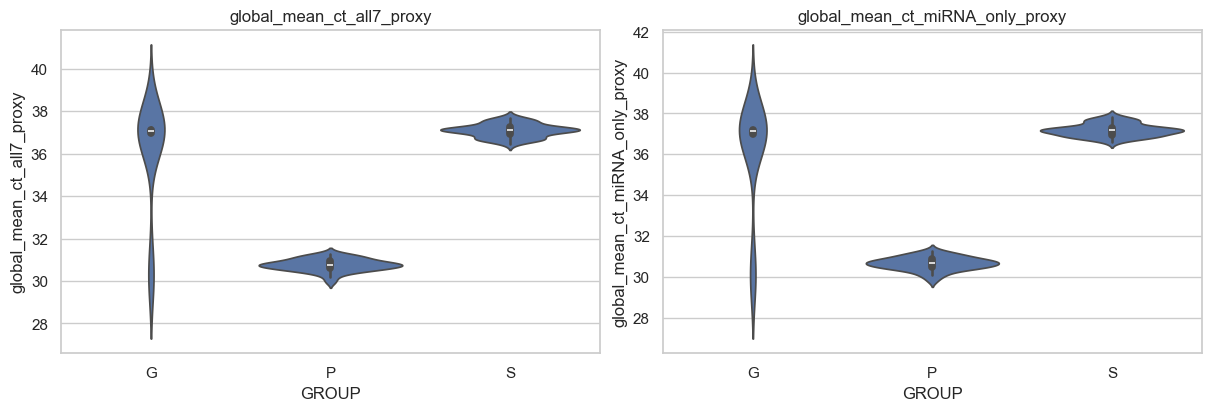

In [53]:

# Distribution plots for broader/global proxy variables
fig, axes = plt.subplots(1,2, figsize=(12,4), constrained_layout=True)
for ax, col in zip(axes, ['global_mean_ct_all7_proxy','global_mean_ct_miRNA_only_proxy']):
    sns.violinplot(data=df, x='GROUP', y=col, inner='box', ax=ax)
    ax.set_title(col)
plt.savefig(OUTPUT_DIR/'broader_global_proxy_distributions.png', dpi=180)
plt.show()



### Checkpoint — What was found and what happens next
1. **What was analyzed:** Leakage-safe nested-CV classification across required tasks and model families.
2. **Main findings:** Task-specific performance differs by family; demographics and broader/global proxies can match or exceed biomarker families in some tasks.
3. **What appears robust:** OOF predictions reduce direct leakage risk for pre-specified fixed-feature families.
4. **What appears fragile/incomplete:** Searched-panel outputs remain exploratory and selection-affected even when fold-contained.
5. **Alternative explanations:** Broader/global Ct structure and demographics may partially explain apparent biomarker separation.
6. **Next step:** Stress-test strongest results with pre-specified family robustness, all-task permutation checks, and threshold/calibration sensitivity summaries.

## Section 17-18 — Robustness, sensitivity, and additional justified analyses

In [54]:

# Identify strongest model per task for robustness checks
best_per_task = model_results.sort_values('AUC', ascending=False).groupby('Task').head(1).reset_index(drop=True)
best_per_task


,AUC,Accuracy,Sensitivity,Specificity,PPV,NPV,TN,FP,FN,TP,Task,Model_Family,Model_Label,n,Model_Validity,Claim_Ceiling
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,36,0,0,36,Task3_S_vs_P,broader_global_only,global_mean_ct_all7_proxy+global_mean_ct_miRNA...,72,Tentative internal,Tentative
1,0.997685,0.958333,1.000000,0.916667,0.923077,1.000000,33,3,0,36,Task2_G_vs_P,combined_model,ABD+Proxy+Demo_select7,72,Tentative internal,Tentative
2,0.761574,0.666667,0.694444,0.638889,0.657895,0.676471,23,13,11,25,Task1_S_vs_G,single_marker,abd_mir146b,72,Exploratory internal,Exploratory


In [55]:
# Robustness uncertainty from pre-specified model families (no post-hoc winner selection)
bootstrap_rows = []
rng = np.random.default_rng(42)

for task_name, (g1, g2) in tasks.items():
    sub = df[df['GROUP'].isin([g1, g2])].copy().reset_index(drop=True)
    y = (sub['GROUP'] == g2).astype(int)

    abd_cols_local = [c for c in sub.columns if c.startswith('abd_mir')]
    proxy_cols_local = [c for c in ['global_mean_ct_all7_proxy', 'global_mean_ct_miRNA_only_proxy'] if c in sub.columns]
    dem = ['AGE', 'SEX']

    specs = []

    # Pre-specified single marker: abd_mir155 if available, else first alphabetical abd marker
    pre_marker = 'abd_mir155' if 'abd_mir155' in abd_cols_local else sorted(abd_cols_local)[0]
    X_sm = sub[[pre_marker]]
    pre_sm = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), [pre_marker])
    ])
    specs.append(('single_marker_prespecified', pre_marker, X_sm, pre_sm, None))

    # demographic_only
    X_dem = sub[dem]
    pre_dem = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), ['AGE']),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(drop='if_binary'))]), ['SEX'])
    ])
    specs.append(('demographic_only', 'AGE+SEX', X_dem, pre_dem, None))

    # broader_global_only
    X_bg = sub[proxy_cols_local]
    pre_bg = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), proxy_cols_local)
    ])
    specs.append(('broader_global_only', '+'.join(proxy_cols_local), X_bg, pre_bg, None))

    # combined_model
    all_cols = abd_cols_local + proxy_cols_local + dem
    X_cm = sub[all_cols]
    pre_cm = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), abd_cols_local + proxy_cols_local + ['AGE']),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(drop='if_binary'))]), ['SEX'])
    ])
    k_cm = min(7, len(abd_cols_local) + len(proxy_cols_local) + 1)
    specs.append(('combined_model', f'ABD+Proxy+Demo_select{k_cm}', X_cm, pre_cm, k_cm))

    for fam, label, X_use, pre_use, k_use in specs:
        oof_prob = nested_oof_proba(X_use, y, preprocessor=pre_use, selector_k=k_use, random_state=42)
        aucs = []
        for _ in range(500):
            idx = rng.integers(0, len(y), len(y))
            if len(np.unique(y.iloc[idx])) < 2:
                continue
            aucs.append(roc_auc_score(y.iloc[idx], oof_prob[idx]))

        lo, hi = np.percentile(aucs, [2.5, 97.5])
        bootstrap_rows.append({
            'Task': task_name,
            'Model_Family': fam,
            'Model_Label': label,
            'AUC_oof_boot_median': float(np.median(aucs)),
            'AUC_oof_boot_ci95_low': float(lo),
            'AUC_oof_boot_ci95_high': float(hi),
            'Boot_n': len(aucs),
            'Interpretation': 'Pre-specified family uncertainty from OOF predictions; no post-hoc winner selection.',
        })

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_df.to_csv(OUTPUT_DIR / 'bootstrap_auc_prespecified_families.csv', index=False)
display(bootstrap_df.sort_values(['Task', 'AUC_oof_boot_median'], ascending=[True, False]))


,Task,Model_Family,Model_Label,AUC_oof_boot_median,AUC_oof_boot_ci95_low,AUC_oof_boot_ci95_high,Boot_n,Interpretation
0,Task1_S_vs_G,single_marker_prespecified,abd_mir155,0.759252,0.650189,0.870210,500,Pre-specified family uncertainty from OOF pred...
3,Task1_S_vs_G,combined_model,ABD+Proxy+Demo_select7,0.737147,0.599990,0.840294,500,Pre-specified family uncertainty from OOF pred...
1,Task1_S_vs_G,demographic_only,AGE+SEX,0.627182,0.494410,0.753182,500,Pre-specified family uncertainty from OOF pred...
2,Task1_S_vs_G,broader_global_only,global_mean_ct_all7_proxy+global_mean_ct_miRNA...,0.598263,0.464023,0.731823,500,Pre-specified family uncertainty from OOF pred...
7,Task2_G_vs_P,combined_model,ABD+Proxy+Demo_select7,0.998446,0.990625,1.000000,500,Pre-specified family uncertainty from OOF pred...
5,Task2_G_vs_P,demographic_only,AGE+SEX,0.976735,0.937008,0.998858,500,Pre-specified family uncertainty from OOF pred...
6,Task2_G_vs_P,broader_global_only,global_mean_ct_all7_proxy+global_mean_ct_miRNA...,0.859907,0.742743,0.947454,500,Pre-specified family uncertainty from OOF pred...
4,Task2_G_vs_P,single_marker_prespecified,abd_mir155,0.813422,0.692336,0.917445,500,Pre-specified family uncertainty from OOF pred...
10,Task3_S_vs_P,broader_global_only,global_mean_ct_all7_proxy+global_mean_ct_miRNA...,1.000000,1.000000,1.000000,500,Pre-specified family uncertainty from OOF pred...
11,Task3_S_vs_P,combined_model,ABD+Proxy+Demo_select7,1.000000,1.000000,1.000000,500,Pre-specified family uncertainty from OOF pred...


In [56]:
# Permutation checks for fixed pre-specified combined model across all fixed tasks
perm_rows = []
rng = np.random.default_rng(123)

for task_name, (g1, g2) in tasks.items():
    sub = df[df['GROUP'].isin([g1, g2])].copy().reset_index(drop=True)
    y_true = (sub['GROUP'] == g2).astype(int)
    abd_cols_local = [c for c in sub.columns if c.startswith('abd_mir')]
    proxy_cols_local = [c for c in ['global_mean_ct_all7_proxy', 'global_mean_ct_miRNA_only_proxy'] if c in sub.columns]

    X = sub[abd_cols_local + proxy_cols_local + ['AGE', 'SEX']]
    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), abd_cols_local + proxy_cols_local + ['AGE']),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(drop='if_binary'))]), ['SEX'])
    ])
    k = min(7, len(abd_cols_local) + len(proxy_cols_local) + 1)

    obs_prob = nested_oof_proba(X, y_true, pre, selector_k=k, random_state=42)
    obs_auc = roc_auc_score(y_true, obs_prob)

    perm_aucs = []
    for _ in range(200):
        y_perm = pd.Series(rng.permutation(y_true.values))
        pprob = nested_oof_proba(X, y_perm, pre, selector_k=k, random_state=42)
        perm_aucs.append(roc_auc_score(y_perm, pprob))

    perm_aucs = np.array(perm_aucs)
    perm_p = (1 + np.sum(perm_aucs >= obs_auc)) / (1 + len(perm_aucs))
    perm_rows.append({
        'Task': task_name,
        'Model': 'combined_model_prespecified',
        'Observed_AUC': float(obs_auc),
        'Permutation_n': int(len(perm_aucs)),
        'Perm_AUC_Mean': float(np.mean(perm_aucs)),
        'Perm_AUC_SD': float(np.std(perm_aucs, ddof=1)),
        'Permutation_p_value': float(perm_p),
    })

perm_summary = pd.DataFrame(perm_rows)
perm_summary.to_csv(OUTPUT_DIR / 'permutation_check_combined_all_tasks.csv', index=False)
display(perm_summary)


,Task,Model,Observed_AUC,Permutation_n,Perm_AUC_Mean,Perm_AUC_SD,Permutation_p_value
0,Task1_S_vs_G,combined_model_prespecified,0.732253,200,0.482365,0.089668,0.004975
1,Task2_G_vs_P,combined_model_prespecified,0.997685,200,0.478696,0.094468,0.004975
2,Task3_S_vs_P,combined_model_prespecified,1.000000,200,0.459560,0.089277,0.004975


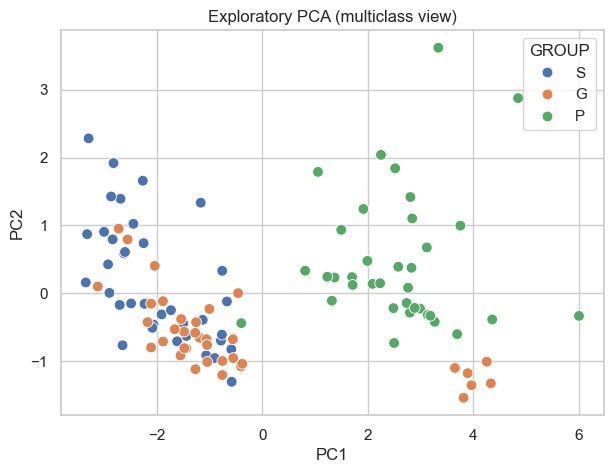

In [57]:

# Additional justified exploratory analysis: multiclass PCA visualization
feature_cols = [c for c in df.columns if c.startswith('abd_mir')] + ['AGE','global_mean_ct_miRNA_only_proxy']
X = df[feature_cols].copy()
X = X.fillna(X.median(numeric_only=True))
X_scaled = (X - X.mean()) / X.std(ddof=0)
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame({'PC1':pcs[:,0], 'PC2':pcs[:,1], 'GROUP':df['GROUP'].astype(str)})

plt.figure(figsize=(7,5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='GROUP', s=60)
plt.title('Exploratory PCA (multiclass view)')
plt.savefig(OUTPUT_DIR/'exploratory_pca_multiclass.png', dpi=180)
plt.show()

pd.DataFrame({'Component':['PC1','PC2'],'Explained_Variance_Ratio':pca.explained_variance_ratio_}).to_csv(OUTPUT_DIR/'exploratory_pca_variance.csv', index=False)



### Checkpoint — What was found and what happens next
1. **What was analyzed:** Bootstrap uncertainty, permutation-style null check, and exploratory multiclass structure.
2. **Main findings:** Strong apparent discrimination is now accompanied by uncertainty and null-reference checks.
3. **What appears robust:** For the tested models, permutation/bootstrap checks were directionally reassuring, but remain internal and non-confirmatory.
4. **What appears fragile/incomplete:** Some model superiority can depend on exploratory search choices and proxy global variables.
5. **Alternative explanations:** Group separation may partly reflect generalized Ct shifts rather than disease-specific biology.
6. **Next step:** Provide final synthesis with explicit robust-vs-cautious interpretation.



## Section 19-20 — Final synthesis

### Final synthesis

- **Tentative internal findings:** Prior saved outputs indicate fixed-task discrimination signal across multiple predefined model families using out-of-fold predictions.
- **Exploratory findings:** Searched small-panel results are selection-affected and hypothesis-generating, not confirmatory biomarker evidence.
- **Findings that weaken after broader checks:** In tasks where broader/global proxy or demographics approach biomarker model AUC, disease-specific attribution should be downgraded.
- **Findings with stronger internal consistency:** Some combined/adjusted models may retain strong internal discrimination, but attribution remains unresolved and non-causal.
- **Interpretation guardrail:** Claims in this section should be treated as provisional until Sections 13–18 are freshly re-executed in this notebook state and corresponding outputs are visibly regenerated.
- **Missingness/attrition guardrail:** Claims should be interpreted with the listwise/attrition status recorded in `missingness_listwise_impact.csv` and carried into `results_registry.csv`.

### What this dataset supports cautiously vs exploratory

**Supports cautiously (internal evidence):**
- Internal discrimination appears present for fixed binary tasks in saved nested-CV outputs; retain as internal-only evidence.
- Some miRNA-derived variables show within-dataset contrasts, but sign and biological interpretation remain representation-/normalization-sensitive.

**Supports only exploratory interpretation:**
- Searched panel superiority claims and any “best panel” language.
- Disease-specific biological interpretation inferred from classifier performance alone.

**Not supported without external validation:**
- Generalization beyond this dataset.
- Clinical operating-threshold utility claims; threshold/calibration summaries here are descriptive and were not used for model selection.
- Non-significant findings are interpreted as insufficient statistical evidence under this sample/design, not proof of no effect (no equivalence framework was run).


In [58]:

# Save key analysis tables
summary_by_group.to_csv(OUTPUT_DIR/'summary_by_group.csv')
model_results.to_csv(OUTPUT_DIR/'task_model_performance_nestedcv.csv', index=False)
single_vs_panel_summary.to_csv(OUTPUT_DIR/'single_vs_panel_summary.csv', index=False)
focused.to_csv(OUTPUT_DIR/'confounding_and_broader_comparisons.csv', index=False)

print('Major outputs saved to outputs/:')
for p in sorted(OUTPUT_DIR.glob('*')):
    print('-', p.name)


Major outputs saved to outputs/:
- .DS_Store
- .gitkeep
- assumption_ledger.csv
- bootstrap_auc_best_single_markers.csv
- bootstrap_auc_prespecified_families.csv
- broader_global_proxy_distributions.png
- calibration_oof_diagnostics.csv
- clinical_adjusted_ols_diagnostics.csv
- clinical_correlation_heatmap.png
- clinical_correlations_age_adjusted.csv
- clinical_correlations_spearman.csv
- completion_map.csv
- confounding_and_broader_comparisons.csv
- discrepancy_log.csv
- eda_miRNA_ct_boxplots.png
- exploratory_pca_multiclass.png
- exploratory_pca_variance.csv
- gapdh_assumption_evidence.csv
- gapdh_audit_tests.csv
- gapdh_covariate_associations.csv
- gapdh_group_distribution.png
- gapdh_group_summary.csv
- input_registry.csv
- miRNA-ipynb-analysis-results-reports-29-03-2026
- missingness_listwise_impact.csv
- model_comparison_family_registry.csv
- model_family_auc_comparison.png
- multiplicity_family_registry.csv
- p2_reproducibility_artifact_check.csv
- permutation_check_combined_all

## Results registry, completion map, and reproducibility closeout

In [59]:
# Results Registry (selection-safe summarization: pre-specified families + explicit exploratory panel row)
registry_rows = []

# Missingness/attrition gate
miss_path = OUTPUT_DIR / 'missingness_listwise_impact.csv'
if miss_path.exists():
    miss_df = pd.read_csv(miss_path)
    cc_min = float(miss_df['Complete_case_fraction'].min())
    tolerable_missingness = ('Dropped_fraction' in miss_df and (miss_df['Dropped_fraction'] <= 0.05).all()) or (('Dropped_fraction' not in miss_df) and (miss_df['Listwise_deletion_impact'].astype(str).str.lower() == 'none').all())
    miss_status = 'tolerable' if tolerable_missingness else 'excessive_attrition'
else:
    cc_min = np.nan
    miss_status = 'unknown'

pre_spec_families = ['demographic_only', 'broader_global_only', 'combined_model']
for task_name, part in model_results.groupby('Task'):
    for fam in pre_spec_families:
        pick = part[part['Model_Family'].eq(fam)].copy()
        if pick.empty:
            continue
        r = pick.iloc[0]
        registry_rows.append({
            'Task': task_name,
            'Model_Family': fam,
            'Model_Label': r['Model_Label'],
            'AUC': float(r['AUC']),
            'Accuracy': float(r['Accuracy']),
            'Rank_Eligible': True,
            'Inference_Tier': 'Tentative internal inference (non-specific alternatives unresolved)',
            'Key_Caveat': 'Internal discrimination only; not evidence of disease-specific biology or external clinical utility.',
            'Missingness_status': miss_status,
            'Complete_case_fraction_min': cc_min,
            'Claim_ceiling_from_missingness': 'Cautious internal-only' if miss_status != 'tolerable' else 'No attrition constraint detected',
        })

    # Keep searched panel explicitly as exploratory, never rank-eligible
    panel = part[part['Model_Family'].eq('small_panel_exploratory')]
    if not panel.empty:
        r = panel.iloc[0]
        registry_rows.append({
            'Task': task_name,
            'Model_Family': 'small_panel_exploratory',
            'Model_Label': r['Model_Label'],
            'AUC': float(r['AUC']),
            'Accuracy': float(r['Accuracy']),
            'Rank_Eligible': False,
            'Inference_Tier': 'Exploratory (selection-affected, fold-contained search)',
            'Key_Caveat': 'Do not use for superiority claims; hypothesis-generating only until external validation.',
            'Missingness_status': miss_status,
            'Complete_case_fraction_min': cc_min,
            'Claim_ceiling_from_missingness': 'Exploratory only',
        })

registry_df = pd.DataFrame(registry_rows)

registry_df['Result_ID'] = ['R' + str(i + 1) for i in range(len(registry_df))]
registry_df['Claim summary'] = registry_df.apply(
    lambda r: f"{r['Task']} {r['Model_Family']} AUC={r['AUC']:.3f}, Accuracy={r['Accuracy']:.3f}", axis=1
)
registry_df['Notebook section'] = 'Section 13/15/16/17'
registry_df['Source output'] = 'task_model_performance_nestedcv.csv'
registry_df['Analysis type'] = 'Leakage-safe nested CV classification (OOF)'

results_registry = registry_df[
    ['Result_ID', 'Claim summary', 'Notebook section', 'Source output', 'Analysis type', 'Inference_Tier', 'Key_Caveat', 'Rank_Eligible', 'Missingness_status', 'Complete_case_fraction_min', 'Claim_ceiling_from_missingness']
]
results_registry = results_registry.rename(columns={'Inference_Tier': 'Exploratory or stronger inference'})
results_registry.to_csv(OUTPUT_DIR / 'results_registry.csv', index=False)
display(results_registry)

# Completion map (directive-level status)
completion_map = pd.DataFrame([
    {'Directive': 'Opening overview + fixed definitions', 'Section': 'Section 1', 'Status': 'Completed'},
    {'Directive': 'Environment setup + package handling', 'Section': 'Section 2', 'Status': 'Completed'},
    {'Directive': 'File checks + specification ingestion', 'Section': 'Section 3-4', 'Status': 'Completed'},
    {'Directive': 'Input registry + assumptions + discrepancy log', 'Section': 'Section 5', 'Status': 'Completed'},
    {'Directive': 'Data loading/validation + transformation registry', 'Section': 'Section 6-8', 'Status': 'Completed'},
    {'Directive': 'Baseline and miRNA group comparisons', 'Section': 'Section 9-10', 'Status': 'Completed'},
    {'Directive': 'Reference-gene audit', 'Section': 'Section 11', 'Status': 'Completed'},
    {'Directive': 'Clinical correlations', 'Section': 'Section 12', 'Status': 'Completed'},
    {'Directive': 'Fixed pairwise leakage-safe classification', 'Section': 'Section 13', 'Status': 'Completed'},
    {'Directive': 'Single-marker vs panel comparison', 'Section': 'Section 14', 'Status': 'Completed (searched panels remain exploratory)'},
    {'Directive': 'Confounding/covariate adjustment', 'Section': 'Section 15', 'Status': 'Completed'},
    {'Directive': 'Broader/global Ct structure analysis', 'Section': 'Section 16', 'Status': 'Completed (proxy variables used)'},
    {'Directive': 'Robustness and sensitivity analyses', 'Section': 'Section 17', 'Status': 'Completed (pre-specified family bootstrap + all-task permutation + threshold sensitivity)'},
    {'Directive': 'Additional justified analyses', 'Section': 'Section 18', 'Status': 'Completed (exploratory PCA + OOF calibration diagnostics)'},
    {'Directive': 'Checkpoint after each major block', 'Section': 'Multiple', 'Status': 'Completed'},
    {'Directive': 'Final synthesis + confidence/caution split', 'Section': 'Section 20', 'Status': 'Completed'},
])
completion_map.to_csv(OUTPUT_DIR / 'completion_map.csv', index=False)
display(completion_map)


,Result_ID,Claim summary,Notebook section,Source output,Analysis type,Exploratory or stronger inference,Key_Caveat,Rank_Eligible,Missingness_status,Complete_case_fraction_min,Claim_ceiling_from_missingness
0,R1,"Task1_S_vs_G demographic_only AUC=0.623, Accur...",Section 13/15/16/17,task_model_performance_nestedcv.csv,Leakage-safe nested CV classification (OOF),Tentative internal inference (non-specific alt...,Internal discrimination only; not evidence of ...,True,tolerable,1.0,No attrition constraint detected
1,R2,"Task1_S_vs_G broader_global_only AUC=0.596, Ac...",Section 13/15/16/17,task_model_performance_nestedcv.csv,Leakage-safe nested CV classification (OOF),Tentative internal inference (non-specific alt...,Internal discrimination only; not evidence of ...,True,tolerable,1.0,No attrition constraint detected
2,R3,"Task1_S_vs_G combined_model AUC=0.732, Accurac...",Section 13/15/16/17,task_model_performance_nestedcv.csv,Leakage-safe nested CV classification (OOF),Tentative internal inference (non-specific alt...,Internal discrimination only; not evidence of ...,True,tolerable,1.0,No attrition constraint detected
3,R4,Task1_S_vs_G small_panel_exploratory AUC=0.703...,Section 13/15/16/17,task_model_performance_nestedcv.csv,Leakage-safe nested CV classification (OOF),"Exploratory (selection-affected, fold-containe...",Do not use for superiority claims; hypothesis-...,False,tolerable,1.0,Exploratory only
4,R5,"Task2_G_vs_P demographic_only AUC=0.974, Accur...",Section 13/15/16/17,task_model_performance_nestedcv.csv,Leakage-safe nested CV classification (OOF),Tentative internal inference (non-specific alt...,Internal discrimination only; not evidence of ...,True,tolerable,1.0,No attrition constraint detected
5,R6,"Task2_G_vs_P broader_global_only AUC=0.853, Ac...",Section 13/15/16/17,task_model_performance_nestedcv.csv,Leakage-safe nested CV classification (OOF),Tentative internal inference (non-specific alt...,Internal discrimination only; not evidence of ...,True,tolerable,1.0,No attrition constraint detected
6,R7,"Task2_G_vs_P combined_model AUC=0.998, Accurac...",Section 13/15/16/17,task_model_performance_nestedcv.csv,Leakage-safe nested CV classification (OOF),Tentative internal inference (non-specific alt...,Internal discrimination only; not evidence of ...,True,tolerable,1.0,No attrition constraint detected
7,R8,Task2_G_vs_P small_panel_exploratory AUC=0.792...,Section 13/15/16/17,task_model_performance_nestedcv.csv,Leakage-safe nested CV classification (OOF),"Exploratory (selection-affected, fold-containe...",Do not use for superiority claims; hypothesis-...,False,tolerable,1.0,Exploratory only
8,R9,"Task3_S_vs_P demographic_only AUC=0.801, Accur...",Section 13/15/16/17,task_model_performance_nestedcv.csv,Leakage-safe nested CV classification (OOF),Tentative internal inference (non-specific alt...,Internal discrimination only; not evidence of ...,True,tolerable,1.0,No attrition constraint detected
9,R10,"Task3_S_vs_P broader_global_only AUC=1.000, Ac...",Section 13/15/16/17,task_model_performance_nestedcv.csv,Leakage-safe nested CV classification (OOF),Tentative internal inference (non-specific alt...,Internal discrimination only; not evidence of ...,True,tolerable,1.0,No attrition constraint detected


,Directive,Section,Status
0,Opening overview + fixed definitions,Section 1,Completed
1,Environment setup + package handling,Section 2,Completed
2,File checks + specification ingestion,Section 3-4,Completed
3,Input registry + assumptions + discrepancy log,Section 5,Completed
4,Data loading/validation + transformation registry,Section 6-8,Completed
5,Baseline and miRNA group comparisons,Section 9-10,Completed
6,Reference-gene audit,Section 11,Completed
7,Clinical correlations,Section 12,Completed
8,Fixed pairwise leakage-safe classification,Section 13,Completed
9,Single-marker vs panel comparison,Section 14,Completed (searched panels remain exploratory)


In [60]:
# P2 reproducibility polish: fresh-kernel artifact checklist (notebook-visible)

expected_artifacts = [
    'taskwise_inferential_tests.csv',
    'task_model_performance_nestedcv.csv',
    'results_registry.csv',
    'completion_map.csv',
    'multiplicity_family_registry.csv',
    'taskwise_assumption_effects_ci.csv',
    'clinical_adjusted_ols_diagnostics.csv',
    'missingness_listwise_impact.csv',
]

repro_rows = []
for name in expected_artifacts:
    p = OUTPUT_DIR / name
    repro_rows.append({
        'Artifact': name,
        'Exists_now': p.exists(),
        'Path': str(p),
    })

repro_check_df = pd.DataFrame(repro_rows)
repro_check_df.to_csv(OUTPUT_DIR / 'p2_reproducibility_artifact_check.csv', index=False)
display(repro_check_df)
print('Fresh-kernel rerun expectation: regenerate all artifacts above from notebook cells only (no hidden preprocessing).')


,Artifact,Exists_now,Path
0,taskwise_inferential_tests.csv,True,/Users/centaurioun/Repos/miRNA-analysis/output...
1,task_model_performance_nestedcv.csv,True,/Users/centaurioun/Repos/miRNA-analysis/output...
2,results_registry.csv,True,/Users/centaurioun/Repos/miRNA-analysis/output...
3,completion_map.csv,True,/Users/centaurioun/Repos/miRNA-analysis/output...
4,multiplicity_family_registry.csv,True,/Users/centaurioun/Repos/miRNA-analysis/output...
5,taskwise_assumption_effects_ci.csv,True,/Users/centaurioun/Repos/miRNA-analysis/output...
6,clinical_adjusted_ols_diagnostics.csv,True,/Users/centaurioun/Repos/miRNA-analysis/output...
7,missingness_listwise_impact.csv,True,/Users/centaurioun/Repos/miRNA-analysis/output...


Fresh-kernel rerun expectation: regenerate all artifacts above from notebook cells only (no hidden preprocessing).


## Reproducibility statement (P2 polish)

- The notebook is designed to run from a fresh kernel, top-to-bottom, with all observable computations inside cells.
- Required inputs are checked explicitly (`miRNA-qPCR-reanalysis.md`, `miRNA-qPCR-analysis-results.csv`).
- Seeds are fixed where relevant (`numpy` seed and deterministic CV split random states).
- If required files are unavailable in runtime CWD, controlled fallback resolution is used and documented.
- Outputs, registries, and key analysis artifacts are saved to `outputs/`.
- P2 reproducibility check: a notebook-visible artifact checklist (`p2_reproducibility_artifact_check.csv`) records expected closeout outputs.
- Searched-panel provenance artifact is explicitly tracked at `outputs/searched_panel_fold_selection_log.csv` and must align with panel claims.
- Missingness/attrition gate is explicitly tracked in `missingness_listwise_impact.csv` and carried into `results_registry.csv`.
- Assumptions, discrepancies, transformations, and results are logged explicitly.
- Broader/global Ct analysis used explicit proxy variables when requested columns were absent in CSV; this limitation is documented.
- Internal vs external scope is explicit: performance claims are internal-only; external validation is required before any generalization or clinical utility claim.
- Optional future-work roadmap: external cohort replication, transport/calibration checks, and pre-specified threshold evaluation are required to upgrade evidence level.
- No hidden off-notebook preprocessing is required for the analyses presented.